# Bi-Weekly Aggregation Horizon Experiment (Notebook 28)

This notebook implements Dr. Yow's recommendation to:
1. Aggregate daily demand to bi-weekly (14-day) totals
2. Use a longer forecast horizon (14 bi-weekly periods ahead)
3. Test whether deep learning models overcome the flat-forecast
   problem when zero-inflation is reduced through aggregation.

**Reference**: Notebook 27 ran the same 12 models on DAILY data
(horizon=1, test_days=365). This notebook runs on BI-WEEKLY data
(horizon=14 periods, test_periods=14) for direct comparison.

**Hypothesis**: Daily series with 96% zeros cause MSE-optimized
deep models to predict the mean constantly (PDR=0%). Bi-weekly
aggregation reduces zero-inflation and may restore signal.


In [20]:
import importlib
import sys

print('Notebook Python:', sys.executable)

required = ['numpy', 'pandas', 'torch', 'scipy']
missing = []
for pkg in required:
    try:
        importlib.import_module(pkg)
        print(f'OK {pkg}')
    except ModuleNotFoundError:
        missing.append(pkg)

if missing:
    raise ModuleNotFoundError(
        f'Missing packages in this kernel: {missing}. Install them in the notebook kernel before running.'
    )
else:
    print('All required packages are available in the current kernel.')


Notebook Python: c:\Users\braya\AppData\Local\Programs\Python\Python311\python.exe
OK numpy
OK pandas
OK torch
OK scipy
All required packages are available in the current kernel.


In [21]:
from pathlib import Path
import sys

def find_repo_root(start: Path) -> Path:
    cur = start.resolve()
    for _ in range(8):
        if (cur / 'src').exists() and (cur / 'reports').exists():
            return cur
        if cur.parent == cur:
            break
        cur = cur.parent
    return start.resolve()

REPO_ROOT = find_repo_root(Path.cwd())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

print('Repo root:', REPO_ROOT)


Repo root: C:\Users\braya\Documents\Research\aurex-demand-forecasting-main


In [22]:

import numpy as np
import pandas as pd
try:
    import matplotlib.pyplot as plt
    MATPLOTLIB_AVAILABLE = True
except Exception as e:
    print('Matplotlib disabled:', e)
    MATPLOTLIB_AVAILABLE = False
    plt = None
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from IPython.display import HTML, display
from scipy.signal import find_peaks

from src.experiments.run_cross_market_peak_comparison import (
    _load_amazon_selected,
    _load_favorita_selected,
    _load_m5_selected,
)
from src.models.advanced_deep_forecast_models import (
    InformerForecastModel,
    LSTMForecastModel as AdvancedLSTMForecastModel,
    LSTMTransformerForecastModel,
    NBEATSForecastModel,
    TCNForecastModel,
    TFTForecastModel,
)
from src.models.croston_model import CrostonSBAModel
from src.models.deep_challenger_models import (
    GRUForecastModel,
    DeepARForecastModel,
    DeepTrainingConfig,
    _as_float_array,
    _build_windows,
    _choose_device,
    _normal_quantile_975,
    _series_scale,
    mae,
    rmse,
    smape,
    train_test_split_series,
)
from src.models.hurdle_model import HurdleModel
from src.models.regime_forecast_engine import RegimeForecastEngine
from src.models.sarimax_model import SARIMAXModel
from src.models.tsb_model import TSBModel, sbc_classify

np.random.seed(42)
torch.manual_seed(42)
print('Imports OK')


Imports OK


In [23]:

m5_ids = ['HOUSEHOLD_1_187_WI_1_validation']
fav_ids = ['item_268443', 'item_789224']
amz_ids = ['B0BZTL57BP', 'B0BR4W8TBH']

series_map_by_ds = {
    'M5_WALMART': _load_m5_selected(str(REPO_ROOT / 'data' / 'raw' / 'm5'), m5_ids),
    'FAVORITA': _load_favorita_selected(str(REPO_ROOT / 'data' / 'raw' / 'favorita'), fav_ids, store_nbr=1),
    'AMAZON_2023': _load_amazon_selected(
        str(REPO_ROOT / 'data' / 'raw' / 'amazon_2023' / 'review_categories'),
        'Health_and_Household.jsonl.gz',
        amz_ids,
        max_rows=200000,
    ),
}

{k: list(v.keys()) for k, v in series_map_by_ds.items()}


{'M5_WALMART': ['HOUSEHOLD_1_187_WI_1_validation'],
 'FAVORITA': ['item_268443', 'item_789224'],
 'AMAZON_2023': ['B0BZTL57BP', 'B0BR4W8TBH']}

In [24]:

def aggregate_to_biweekly(df: pd.DataFrame, period: int = 14) -> pd.DataFrame:
    out = df[['date', 'sales']].copy().sort_values('date').reset_index(drop=True)
    out['date'] = pd.to_datetime(out['date'])
    out['sales'] = pd.to_numeric(out['sales'], errors='coerce').fillna(0.0)
    out['period'] = np.arange(len(out)) // period
    out['sale_flag'] = (out['sales'] > 0).astype(int)

    grouped = out.groupby('period', as_index=False).agg(
        period_start=('date', 'first'),
        sales_total=('sales', 'sum'),
        n_sale_days=('sale_flag', 'sum'),
        period_length=('date', 'size'),
    )
    grouped['zero_rate_within'] = 1.0 - (grouped['n_sale_days'] / period)
    grouped = grouped.sort_values('period_start').reset_index(drop=True)

    if len(grouped) > 0 and int(grouped.iloc[-1]['period_length']) < max(1, period // 2):
        grouped = grouped.iloc[:-1].reset_index(drop=True)

    return grouped[['period_start', 'sales_total', 'n_sale_days', 'zero_rate_within']]


def peak_detection_rate(y_true: np.ndarray, y_pred: np.ndarray, window: int = 1) -> float:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    prominence = max(0.2 * (y_true.max() - y_true.min()), 1e-6)
    true_peaks, _ = find_peaks(y_true, prominence=prominence)
    pred_peaks, _ = find_peaks(y_pred, prominence=prominence * 0.5)
    if len(true_peaks) == 0:
        return float('nan')
    detected = sum(any(abs(tp - pp) <= window for pp in pred_peaks) for tp in true_peaks)
    return detected / len(true_peaks)


def variance_ratio(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    sigma_t = float(np.std(y_true))
    sigma_p = float(np.std(y_pred))
    if sigma_t < 1e-9:
        return float('nan')
    return sigma_p / sigma_t


def trend_correlation(y_true: np.ndarray, y_pred: np.ndarray, window: int = 3) -> float:
    ma_t = pd.Series(y_true).rolling(window, min_periods=1).mean().values
    ma_p = pd.Series(y_pred).rolling(window, min_periods=1).mean().values
    if np.std(ma_t) < 1e-9 or np.std(ma_p) < 1e-9:
        return float('nan')
    return float(np.corrcoef(ma_t, ma_p)[0, 1])


diagnostic_rows = []
for dataset, series_map in series_map_by_ds.items():
    for series_id, df in series_map.items():
        daily_zero_rate = float((pd.to_numeric(df['sales'], errors='coerce').fillna(0.0) == 0).mean())
        bw_df = aggregate_to_biweekly(df, period=14)
        biweekly_zero_rate = float((bw_df['sales_total'] == 0).mean()) if len(bw_df) else float('nan')
        diagnostic_rows.append({
            'dataset': dataset,
            'series_id': series_id,
            'daily_zero_rate': daily_zero_rate,
            'biweekly_zero_rate': biweekly_zero_rate,
            'n_biweekly_periods': len(bw_df),
        })

diagnostic_df = pd.DataFrame(diagnostic_rows).sort_values(['dataset', 'series_id']).reset_index(drop=True)
display(diagnostic_df.round(3))


,dataset,series_id,daily_zero_rate,biweekly_zero_rate,n_biweekly_periods
0,AMAZON_2023,B0BR4W8TBH,0.943,0.472,125
1,AMAZON_2023,B0BZTL57BP,0.957,0.562,208
2,FAVORITA,item_268443,0.176,0.025,121
3,FAVORITA,item_789224,0.081,0.000,121
4,M5_WALMART,HOUSEHOLD_1_187_WI_1_validation,0.926,0.679,137


In [25]:

BIWEEKLY_PERIOD = 14
BIWEEKLY_HORIZON = 14
BIWEEKLY_EPOCHS = 30
BIWEEKLY_CONTEXT = 26
BIWEEKLY_RANDOM_STATE = 42

print(f'BIWEEKLY_PERIOD={BIWEEKLY_PERIOD}')
print(f'BIWEEKLY_HORIZON={BIWEEKLY_HORIZON} bi-weekly periods (~28 weeks ahead)')
print(f'BIWEEKLY_EPOCHS={BIWEEKLY_EPOCHS}')
print(f'BIWEEKLY_CONTEXT={BIWEEKLY_CONTEXT} bi-weekly periods (~1 year)')


BIWEEKLY_PERIOD=14
BIWEEKLY_HORIZON=14 bi-weekly periods (~28 weeks ahead)
BIWEEKLY_EPOCHS=30
BIWEEKLY_CONTEXT=26 bi-weekly periods (~1 year)


In [26]:
class _LSTMNet(nn.Module):
    def __init__(self, hidden_size: int, num_layers: int, dropout: float):
        super().__init__()
        lstm_dropout = dropout if num_layers > 1 else 0.0
        self.lstm = nn.LSTM(
            input_size=1,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=lstm_dropout,
            batch_first=True,
        )
        self.head = nn.Sequential(
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, 1),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        out, _ = self.lstm(x)
        last_hidden = out[:, -1, :]
        return self.head(last_hidden).squeeze(-1)


class LSTMForecastModel:
    def __init__(self, **kwargs):
        self.config = DeepTrainingConfig(**kwargs)
        self.device = _choose_device(self.config.device)
        self.model = _LSTMNet(
            hidden_size=self.config.hidden_size,
            num_layers=self.config.num_layers,
            dropout=self.config.dropout,
        ).to(self.device)
        self.scale_ = 1.0
        self.train_resid_std_ = 0.0
        self.training_history_ = {}

    def fit(self, y_train: np.ndarray):
        torch.manual_seed(self.config.seed)
        np.random.seed(self.config.seed)

        y = _as_float_array(y_train)
        self.scale_ = _series_scale(y)
        y_scaled = (y / self.scale_).astype(np.float32)

        X, target = _build_windows(y_scaled, self.config.context_length)
        ds = TensorDataset(
            torch.from_numpy(X).unsqueeze(-1),
            torch.from_numpy(target),
        )
        loader = DataLoader(ds, batch_size=self.config.batch_size, shuffle=True)

        optimizer = torch.optim.Adam(
            self.model.parameters(),
            lr=self.config.lr,
            weight_decay=self.config.weight_decay,
        )
        loss_fn = nn.MSELoss()

        final_loss = None
        self.model.train()
        for _ in range(self.config.epochs):
            epoch_losses = []
            for batch_x, batch_y in loader:
                batch_x = batch_x.to(self.device)
                batch_y = batch_y.to(self.device)
                optimizer.zero_grad()
                pred = self.model(batch_x)
                loss = loss_fn(pred, batch_y)
                loss.backward()
                optimizer.step()
                epoch_losses.append(float(loss.item()))
            final_loss = float(np.mean(epoch_losses)) if epoch_losses else None

        fitted = self._predict_in_sample_scaled(X) * self.scale_
        resid = y[self.config.context_length:] - fitted
        self.train_resid_std_ = float(np.std(resid)) if len(resid) else 0.0
        self.training_history_ = {'final_loss': final_loss if final_loss is not None else float('nan')}
        return self

    def _predict_in_sample_scaled(self, X: np.ndarray) -> np.ndarray:
        self.model.eval()
        with torch.no_grad():
            tensor_x = torch.from_numpy(X).unsqueeze(-1).to(self.device)
            pred = self.model(tensor_x).detach().cpu().numpy()
        return pred.astype(float)

    def forecast(self, h: int, y_history: np.ndarray):
        history = list((_as_float_array(y_history) / self.scale_).astype(np.float32))
        preds_scaled = []

        self.model.eval()
        with torch.no_grad():
            for _ in range(int(h)):
                context = np.asarray(history[-self.config.context_length:], dtype=np.float32)
                if len(context) < self.config.context_length:
                    context = np.pad(context, (self.config.context_length - len(context), 0))
                x = torch.from_numpy(context).view(1, self.config.context_length, 1).to(self.device)
                next_pred = float(self.model(x).item())
                preds_scaled.append(next_pred)
                history.append(next_pred)

        y_pred = np.maximum(np.asarray(preds_scaled, dtype=float) * self.scale_, 0.0)
        spread = _normal_quantile_975() * max(self.train_resid_std_, 1e-6)
        conf_low = np.maximum(y_pred - spread, 0.0)
        conf_up = y_pred + spread
        return y_pred, conf_low, conf_up


print('LSTM model ready')


LSTM model ready


In [27]:

def prepare_case_biweekly(case: dict, test_periods: int = 14) -> dict:
    ds = case['dataset']
    sid = case['series_id']
    daily_df = series_map_by_ds[ds][sid].copy().sort_values('date').reset_index(drop=True)
    daily_sales = pd.to_numeric(daily_df['sales'], errors='coerce').fillna(0.0).to_numpy(dtype=float)
    bw_df = aggregate_to_biweekly(daily_df, period=BIWEEKLY_PERIOD)
    y = bw_df['sales_total'].to_numpy(dtype=float)
    if len(y) <= test_periods:
        raise ValueError(f'Not enough bi-weekly periods for {sid}: total={len(y)}, test_periods={test_periods}')
    y_train = y[:-test_periods]
    y_test = y[-test_periods:]
    bw_train_df = bw_df.iloc[:-test_periods].copy().reset_index(drop=True)
    bw_test_df = bw_df.iloc[-test_periods:].copy().reset_index(drop=True)
    daily_zero_rate = float((daily_sales == 0).mean())
    biweekly_zero_rate = float((bw_df['sales_total'] == 0).mean()) if len(bw_df) else float('nan')
    return {
        'y_train': y_train,
        'y_test': y_test,
        'bw_df': bw_df,
        'bw_train_df': bw_train_df,
        'bw_test_df': bw_test_df,
        'daily_zero_rate': daily_zero_rate,
        'biweekly_zero_rate': biweekly_zero_rate,
        'n_biweekly_periods': len(bw_df),
        'series_id': sid,
        'dataset': ds,
    }


def evaluate_case_model_biweekly(case: dict, model_name: str, model_spec: dict, prepared_bw: dict) -> dict:
    ds = case['dataset']
    sid = case['series_id']
    y_train = prepared_bw['y_train']
    y_test = prepared_bw['y_test']
    bw_df = prepared_bw['bw_df']
    h = BIWEEKLY_HORIZON
    if len(y_test) != h:
        raise ValueError(f'Expected test horizon {h} but got {len(y_test)} for {sid}')

    model = model_spec['factory']()
    family = model_spec['family']
    X_train = np.ones((len(y_train), 1), dtype=float)
    X_test = np.ones((len(y_test), 1), dtype=float)

    if family == 'feature_based':
        model.fit(y_train, X_train)
        y_pred, conf_low, conf_up = model.forecast(h, X_test)
    elif family == 'hurdle':
        model.fit(X_train, y_train)
        y_pred, conf_low, conf_up = model.forecast(X_test, X_train, y_train)
    elif family == 'intermittent_univariate':
        model.fit(y_train)
        y_pred, conf_low, conf_up = model.forecast(h)
    elif family == 'deep_autoregressive':
        model.fit(y_train)
        y_pred, conf_low, conf_up = model.forecast(h, y_train)
    else:
        raise ValueError(f'Unknown model family: {family}')

    y_pred = np.asarray(y_pred, dtype=float)
    y_test = np.asarray(y_test, dtype=float)
    sbc = sbc_classify(y_train)
    return {
        'model': model_name,
        'model_group': model_spec['group'],
        'model_family': family,
        'dataset': ds,
        'series_id': sid,
        'semantic_product': case['semantic_product'],
        'expected_regime': case['expected_regime'],
        'daily_zero_rate': prepared_bw['daily_zero_rate'],
        'biweekly_zero_rate': prepared_bw['biweekly_zero_rate'],
        'n_train_periods': len(y_train),
        'n_test_periods': len(y_test),
        'sbc_regime_train': sbc.get('regime'),
        'ADI_train': sbc.get('adi'),
        'CV2_train': sbc.get('cv2'),
        'mae': mae(y_test, y_pred),
        'rmse': rmse(y_test, y_pred),
        'smape': smape(y_test, y_pred),
        'final_loss': getattr(model, 'training_history_', {}).get('final_loss'),
        'y_test': y_test,
        'y_pred': y_pred,
        'conf_low': np.asarray(conf_low, dtype=float) if conf_low is not None else None,
        'conf_up': np.asarray(conf_up, dtype=float) if conf_up is not None else None,
        'test_period_starts': bw_df['period_start'].iloc[-len(y_test):].reset_index(drop=True),
        'pdr': peak_detection_rate(y_test, y_pred, window=1),
        'vr': variance_ratio(y_test, y_pred),
        'trend_corr': trend_correlation(y_test, y_pred, window=3),
    }


In [28]:

model_factories_bw = {
    'SARIMAX': {'factory': lambda: SARIMAXModel(), 'family': 'feature_based', 'group': 'existing_strong_baseline'},
    'HURDLE': {'factory': lambda: HurdleModel(), 'family': 'hurdle', 'group': 'existing_strong_baseline'},
    'TSB': {'factory': lambda: TSBModel(use_weekly=False), 'family': 'intermittent_univariate', 'group': 'existing_reference_baseline'},
    'CROSTON_SBA': {'factory': lambda: CrostonSBAModel(use_weekly=False), 'family': 'intermittent_univariate', 'group': 'existing_reference_baseline'},
    'LSTM': {'factory': lambda: LSTMForecastModel(context_length=BIWEEKLY_CONTEXT, epochs=BIWEEKLY_EPOCHS, hidden_size=64, num_layers=2), 'family': 'deep_autoregressive', 'group': 'challenger_model'},
    'GRU': {'factory': lambda: GRUForecastModel(context_length=BIWEEKLY_CONTEXT, epochs=BIWEEKLY_EPOCHS, hidden_size=64, num_layers=2), 'family': 'deep_autoregressive', 'group': 'challenger_model'},
    'DeepAR': {'factory': lambda: DeepARForecastModel(context_length=BIWEEKLY_CONTEXT, epochs=BIWEEKLY_EPOCHS, hidden_size=64, num_layers=2), 'family': 'deep_autoregressive', 'group': 'challenger_model'},
    'TCN': {'factory': lambda: TCNForecastModel(context_length=BIWEEKLY_CONTEXT, epochs=BIWEEKLY_EPOCHS, hidden_size=64, num_layers=2), 'family': 'deep_autoregressive', 'group': 'challenger_model'},
    'Informer': {'factory': lambda: InformerForecastModel(context_length=BIWEEKLY_CONTEXT, epochs=BIWEEKLY_EPOCHS, hidden_size=64, num_layers=2), 'family': 'deep_autoregressive', 'group': 'challenger_model'},
    'TFT': {'factory': lambda: TFTForecastModel(context_length=BIWEEKLY_CONTEXT, epochs=BIWEEKLY_EPOCHS, hidden_size=64, num_layers=2), 'family': 'deep_autoregressive', 'group': 'challenger_model'},
    'N-BEATS': {'factory': lambda: NBEATSForecastModel(context_length=BIWEEKLY_CONTEXT, epochs=BIWEEKLY_EPOCHS, hidden_size=64, num_layers=2), 'family': 'deep_autoregressive', 'group': 'challenger_model'},
    'LSTM-Transformer': {'factory': lambda: LSTMTransformerForecastModel(context_length=BIWEEKLY_CONTEXT, epochs=BIWEEKLY_EPOCHS, hidden_size=64, num_layers=2), 'family': 'deep_autoregressive', 'group': 'challenger_model'},
}

list(model_factories_bw)


['SARIMAX',
 'HURDLE',
 'TSB',
 'CROSTON_SBA',
 'LSTM',
 'GRU',
 'DeepAR',
 'TCN',
 'Informer',
 'TFT',
 'N-BEATS',
 'LSTM-Transformer']

In [29]:
experiment_cases = [
    {
        'dataset': 'FAVORITA',
        'series_id': 'item_268443',
        'expected_regime': 'high-demand',
        'semantic_product': 'Cleaning product - high demand / dense sales',
    },
    {
        'dataset': 'FAVORITA',
        'series_id': 'item_789224',
        'expected_regime': 'erratic',
        'semantic_product': 'Cleaning product - erratic transition case',
    },
    {
        'dataset': 'M5_WALMART',
        'series_id': 'HOUSEHOLD_1_187_WI_1_validation',
        'expected_regime': 'lumpy',
        'semantic_product': 'Household retail - lumpy / zero-heavy',
    },
    {
        'dataset': 'AMAZON_2023',
        'series_id': 'B0BZTL57BP',
        'expected_regime': 'intermittent',
        'semantic_product': 'Household hygiene - intermittent demand',
    },
    {
        'dataset': 'AMAZON_2023',
        'series_id': 'B0BR4W8TBH',
        'expected_regime': 'ultra-sparse intermittent',
        'semantic_product': 'Personal care - ultra sparse intermittent demand',
    },
]

display(pd.DataFrame(experiment_cases))


,dataset,series_id,expected_regime,semantic_product
0,FAVORITA,item_268443,high-demand,Cleaning product - high demand / dense sales
1,FAVORITA,item_789224,erratic,Cleaning product - erratic transition case
2,M5_WALMART,HOUSEHOLD_1_187_WI_1_validation,lumpy,Household retail - lumpy / zero-heavy
3,AMAZON_2023,B0BZTL57BP,intermittent,Household hygiene - intermittent demand
4,AMAZON_2023,B0BR4W8TBH,ultra-sparse intermittent,Personal care - ultra sparse intermittent demand


In [30]:

import time

selected_cases_bw = experiment_cases.copy()
selected_model_items_bw = list(model_factories_bw.items())
total_runs_bw = len(selected_cases_bw) * len(selected_model_items_bw)
prepared_bw_cache = {}
results_bw = []
run_idx = 0
overall_t0 = time.perf_counter()

for case in selected_cases_bw:
    prepared_bw = prepare_case_biweekly(case, test_periods=BIWEEKLY_HORIZON)
    prepared_bw_cache[(case['dataset'], case['series_id'])] = prepared_bw
    print(
        f"Case: {case['series_id']} | daily zero_rate={prepared_bw['daily_zero_rate']:.3f} -> biweekly zero_rate={prepared_bw['biweekly_zero_rate']:.3f}"
    )

print()
print(
    f"Running {len(selected_cases_bw)} cases x {len(selected_model_items_bw)} models = {total_runs_bw} runs "
    f"(horizon={BIWEEKLY_HORIZON}, epochs={BIWEEKLY_EPOCHS}, context={BIWEEKLY_CONTEXT})"
)

for case in selected_cases_bw:
    prepared_bw = prepared_bw_cache[(case['dataset'], case['series_id'])]
    for model_name, model_spec in selected_model_items_bw:
        run_idx += 1
        run_t0 = time.perf_counter()
        print(f"[RUN {run_idx}/{total_runs_bw}] {case['dataset']} | {case['series_id']} | {model_name}")
        try:
            result = evaluate_case_model_biweekly(case, model_name, model_spec, prepared_bw)
            results_bw.append(result)
            run_elapsed = time.perf_counter() - run_t0
            total_elapsed = time.perf_counter() - overall_t0
            avg_per_run = total_elapsed / run_idx
            eta_seconds = avg_per_run * (total_runs_bw - run_idx)
            print(
                f"  -> done in {run_elapsed:.1f}s | MAE={result['mae']:.4f} | PDR={result['pdr'] if pd.notna(result['pdr']) else float('nan'):.3f} | elapsed={total_elapsed/60:.1f}m | ETA={eta_seconds/60:.1f}m"
            )
        except Exception as exc:
            run_elapsed = time.perf_counter() - run_t0
            print(f"[WARN] {model_name} failed on {case['series_id']} after {run_elapsed:.1f}s: {exc}")

results_bw_rows = [
    {k: v for k, v in row.items() if k not in ['y_test', 'y_pred', 'conf_low', 'conf_up', 'test_period_starts']}
    for row in results_bw
]
results_bw_df = pd.DataFrame(results_bw_rows).sort_values(['dataset', 'series_id', 'mae']).reset_index(drop=True)
reports_dir = REPO_ROOT / 'reports' / 'paper_experiments'
reports_dir.mkdir(parents=True, exist_ok=True)
results_bw_df.to_csv(reports_dir / '28_biweekly_results.csv', index=False)
print(f"Saved detailed results to {reports_dir / '28_biweekly_results.csv'}")
display(results_bw_df.round(4))


Case: item_268443 | daily zero_rate=0.176 -> biweekly zero_rate=0.025
Case: item_789224 | daily zero_rate=0.081 -> biweekly zero_rate=0.000
Case: HOUSEHOLD_1_187_WI_1_validation | daily zero_rate=0.926 -> biweekly zero_rate=0.679
Case: B0BZTL57BP | daily zero_rate=0.957 -> biweekly zero_rate=0.562
Case: B0BR4W8TBH | daily zero_rate=0.943 -> biweekly zero_rate=0.472

Running 5 cases x 12 models = 60 runs (horizon=14, epochs=30, context=26)
[RUN 1/60] FAVORITA | item_268443 | SARIMAX
  -> done in 0.1s | MAE=58.5066 | PDR=1.000 | elapsed=0.0m | ETA=0.2m
[RUN 2/60] FAVORITA | item_268443 | HURDLE
  -> done in 0.0s | MAE=31.0124 | PDR=0.000 | elapsed=0.0m | ETA=0.1m
[RUN 3/60] FAVORITA | item_268443 | TSB
  -> done in 0.0s | MAE=60.8883 | PDR=0.000 | elapsed=0.0m | ETA=0.1m
[RUN 4/60] FAVORITA | item_268443 | CROSTON_SBA
  -> done in 0.0s | MAE=53.3921 | PDR=0.000 | elapsed=0.0m | ETA=0.0m
[RUN 5/60] FAVORITA | item_268443 | LSTM


C:\Users\braya\AppData\Local\Temp\ipykernel_44808\2678999256.py:52: UserWarning: 
[TSBModel] Series is in 'smooth' regime (ADI=1.01, CV²=0.120).  TSB is optimal in the 'intermittent' quadrant (ADI > 1.32, CV² < 0.49).  Consider using SARIMAX for this product instead.
  model.fit(y_train)


  -> done in 0.7s | MAE=63.7546 | PDR=0.000 | elapsed=0.0m | ETA=0.2m
[RUN 6/60] FAVORITA | item_268443 | GRU
  -> done in 3.1s | MAE=63.9349 | PDR=0.000 | elapsed=0.1m | ETA=0.6m
[RUN 7/60] FAVORITA | item_268443 | DeepAR
  -> done in 0.9s | MAE=77.6871 | PDR=0.000 | elapsed=0.1m | ETA=0.6m
[RUN 8/60] FAVORITA | item_268443 | TCN
  -> done in 1.4s | MAE=64.4045 | PDR=0.000 | elapsed=0.1m | ETA=0.7m
[RUN 9/60] FAVORITA | item_268443 | Informer
  -> done in 3.7s | MAE=79.2542 | PDR=0.000 | elapsed=0.2m | ETA=0.9m
[RUN 10/60] FAVORITA | item_268443 | TFT
  -> done in 1.5s | MAE=61.7972 | PDR=0.000 | elapsed=0.2m | ETA=1.0m
[RUN 11/60] FAVORITA | item_268443 | N-BEATS
  -> done in 0.7s | MAE=72.3521 | PDR=0.000 | elapsed=0.2m | ETA=0.9m
[RUN 12/60] FAVORITA | item_268443 | LSTM-Transformer
  -> done in 2.4s | MAE=47.6483 | PDR=0.000 | elapsed=0.2m | ETA=1.0m
[RUN 13/60] FAVORITA | item_789224 | SARIMAX
  -> done in 0.2s | MAE=15.0799 | PDR=1.000 | elapsed=0.2m | ETA=0.9m
[RUN 14/60] FAVOR

C:\Users\braya\AppData\Local\Temp\ipykernel_44808\2678999256.py:52: UserWarning: 
[TSBModel] Series is in 'smooth' regime (ADI=1.00, CV²=0.223).  TSB is optimal in the 'intermittent' quadrant (ADI > 1.32, CV² < 0.49).  Consider using SARIMAX for this product instead.
  model.fit(y_train)


  -> done in 0.8s | MAE=9.9065 | PDR=0.000 | elapsed=0.3m | ETA=0.7m
[RUN 18/60] FAVORITA | item_789224 | GRU
  -> done in 2.4s | MAE=13.6545 | PDR=0.000 | elapsed=0.3m | ETA=0.7m
[RUN 19/60] FAVORITA | item_789224 | DeepAR
  -> done in 0.7s | MAE=12.0405 | PDR=0.000 | elapsed=0.3m | ETA=0.7m
[RUN 20/60] FAVORITA | item_789224 | TCN
  -> done in 1.1s | MAE=25.6700 | PDR=0.000 | elapsed=0.3m | ETA=0.7m
[RUN 21/60] FAVORITA | item_789224 | Informer
  -> done in 3.7s | MAE=38.3812 | PDR=0.000 | elapsed=0.4m | ETA=0.7m
[RUN 22/60] FAVORITA | item_789224 | TFT
  -> done in 1.9s | MAE=18.6443 | PDR=0.000 | elapsed=0.4m | ETA=0.7m
[RUN 23/60] FAVORITA | item_789224 | N-BEATS
  -> done in 0.9s | MAE=32.5212 | PDR=0.000 | elapsed=0.4m | ETA=0.7m
[RUN 24/60] FAVORITA | item_789224 | LSTM-Transformer
  -> done in 2.6s | MAE=19.6706 | PDR=0.000 | elapsed=0.5m | ETA=0.7m
[RUN 25/60] M5_WALMART | HOUSEHOLD_1_187_WI_1_validation | SARIMAX
  -> done in 0.2s | MAE=1.8463 | PDR=0.400 | elapsed=0.5m | ET

C:\Users\braya\AppData\Local\Temp\ipykernel_44808\2678999256.py:52: UserWarning: 
[TSBModel] Series is in 'lumpy' regime (ADI=1.82, CV²=0.502).  TSB is optimal in the 'intermittent' quadrant (ADI > 1.32, CV² < 0.49).  Consider using HURDLE for this product instead.
  model.fit(y_train)


  -> done in 0.6s | MAE=0.6683 | PDR=0.000 | elapsed=1.1m | ETA=0.1m
[RUN 54/60] AMAZON_2023 | B0BR4W8TBH | GRU
  -> done in 2.3s | MAE=0.6604 | PDR=0.000 | elapsed=1.2m | ETA=0.1m
[RUN 55/60] AMAZON_2023 | B0BR4W8TBH | DeepAR
  -> done in 0.6s | MAE=0.6468 | PDR=0.000 | elapsed=1.2m | ETA=0.1m
[RUN 56/60] AMAZON_2023 | B0BR4W8TBH | TCN
  -> done in 1.1s | MAE=1.1609 | PDR=1.000 | elapsed=1.2m | ETA=0.1m
[RUN 57/60] AMAZON_2023 | B0BR4W8TBH | Informer
  -> done in 2.6s | MAE=0.5365 | PDR=0.250 | elapsed=1.2m | ETA=0.1m
[RUN 58/60] AMAZON_2023 | B0BR4W8TBH | TFT
  -> done in 1.4s | MAE=0.6972 | PDR=0.000 | elapsed=1.3m | ETA=0.0m
[RUN 59/60] AMAZON_2023 | B0BR4W8TBH | N-BEATS
  -> done in 0.8s | MAE=0.6642 | PDR=0.250 | elapsed=1.3m | ETA=0.0m
[RUN 60/60] AMAZON_2023 | B0BR4W8TBH | LSTM-Transformer
  -> done in 2.0s | MAE=0.8538 | PDR=0.000 | elapsed=1.3m | ETA=0.0m
Saved detailed results to C:\Users\braya\Documents\Research\aurex-demand-forecasting-main\reports\paper_experiments\28_biw

,model,model_group,model_family,dataset,series_id,semantic_product,expected_regime,daily_zero_rate,biweekly_zero_rate,n_train_periods,...,sbc_regime_train,ADI_train,CV2_train,mae,rmse,smape,final_loss,pdr,vr,trend_corr
0,SARIMAX,existing_strong_baseline,feature_based,AMAZON_2023,B0BR4W8TBH,Personal care - ultra sparse intermittent demand,ultra-sparse intermittent,0.9428,0.4720,111,...,lumpy,1.8197,0.5023,0.5259,0.6471,149.2186,NaN,1.00,0.3485,0.3188
1,CROSTON_SBA,existing_reference_baseline,intermittent_univariate,AMAZON_2023,B0BR4W8TBH,Personal care - ultra sparse intermittent demand,ultra-sparse intermittent,0.9428,0.4720,111,...,lumpy,1.8197,0.5023,0.5331,0.6258,164.9595,NaN,0.00,0.0000,NaN
2,Informer,challenger_model,deep_autoregressive,AMAZON_2023,B0BR4W8TBH,Personal care - ultra sparse intermittent demand,ultra-sparse intermittent,0.9428,0.4720,111,...,lumpy,1.8197,0.5023,0.5365,0.6309,162.9104,0.1842,0.25,0.1711,-0.4995
3,DeepAR,challenger_model,deep_autoregressive,AMAZON_2023,B0BR4W8TBH,Personal care - ultra sparse intermittent demand,ultra-sparse intermittent,0.9428,0.4720,111,...,lumpy,1.8197,0.5023,0.6468,0.7096,141.3901,1.0417,0.00,0.0674,0.5976
4,HURDLE,existing_strong_baseline,hurdle,AMAZON_2023,B0BR4W8TBH,Personal care - ultra sparse intermittent demand,ultra-sparse intermittent,0.9428,0.4720,111,...,lumpy,1.8197,0.5023,0.6592,0.7288,140.7327,NaN,0.00,0.0000,NaN
5,GRU,challenger_model,deep_autoregressive,AMAZON_2023,B0BR4W8TBH,Personal care - ultra sparse intermittent demand,ultra-sparse intermittent,0.9428,0.4720,111,...,lumpy,1.8197,0.5023,0.6604,0.7376,139.0168,0.4798,0.00,0.0810,0.6359
6,N-BEATS,challenger_model,deep_autoregressive,AMAZON_2023,B0BR4W8TBH,Personal care - ultra sparse intermittent demand,ultra-sparse intermittent,0.9428,0.4720,111,...,lumpy,1.8197,0.5023,0.6642,0.7200,144.4816,0.0018,0.25,0.5816,0.4344
7,LSTM,challenger_model,deep_autoregressive,AMAZON_2023,B0BR4W8TBH,Personal care - ultra sparse intermittent demand,ultra-sparse intermittent,0.9428,0.4720,111,...,lumpy,1.8197,0.5023,0.6683,0.7481,138.8098,0.4883,0.00,0.0324,0.6280
8,TSB,existing_reference_baseline,intermittent_univariate,AMAZON_2023,B0BR4W8TBH,Personal care - ultra sparse intermittent demand,ultra-sparse intermittent,0.9428,0.4720,111,...,lumpy,1.8197,0.5023,0.6707,0.7505,139.0689,NaN,0.00,0.0000,NaN
9,TFT,challenger_model,deep_autoregressive,AMAZON_2023,B0BR4W8TBH,Personal care - ultra sparse intermittent demand,ultra-sparse intermittent,0.9428,0.4720,111,...,lumpy,1.8197,0.5023,0.6972,0.8065,135.3767,0.4660,0.00,0.0107,0.4989


In [31]:

if 'results_bw_df' not in globals() or results_bw_df.empty:
    raise RuntimeError('Run cell 11 first so results_bw_df is populated.')

reports_dir = REPO_ROOT / 'reports' / 'paper_experiments'
reports_dir.mkdir(parents=True, exist_ok=True)

daily_mae_reference = {
    'item_268443': {'SARIMAX': 3.672, 'HURDLE': 2.928, 'LSTM': 6.886, 'GRU': 7.082, 'DeepAR': 7.241, 'TCN': 6.935, 'Informer': 6.024, 'TFT': 6.733, 'N-BEATS': 6.479, 'LSTM-Transformer': 5.808, 'TSB': 5.385, 'CROSTON_SBA': 5.517},
    'item_789224': {'SARIMAX': 2.357, 'HURDLE': 2.239, 'LSTM': 3.599, 'GRU': 3.197, 'DeepAR': 3.377, 'TCN': 3.405, 'Informer': 3.300, 'TFT': 4.431, 'N-BEATS': 4.991, 'LSTM-Transformer': 4.991, 'TSB': 2.922, 'CROSTON_SBA': 2.803},
    'B0BZTL57BP': {'SARIMAX': 0.095, 'HURDLE': 0.116, 'LSTM': 0.090, 'GRU': 0.091, 'DeepAR': 0.118, 'TCN': 0.081, 'Informer': 0.078, 'TFT': 0.107, 'N-BEATS': 0.140, 'LSTM-Transformer': 0.036, 'TSB': 0.043, 'CROSTON_SBA': 0.070},
    'B0BR4W8TBH': {'SARIMAX': 0.136, 'HURDLE': 0.064, 'LSTM': 0.119, 'GRU': 0.125, 'DeepAR': 0.151, 'TCN': 0.101, 'Informer': 0.146, 'TFT': 0.106, 'N-BEATS': 0.094, 'LSTM-Transformer': 0.047, 'TSB': 0.096, 'CROSTON_SBA': 0.072},
}

daily_pdr_reference = {
    'item_268443': {'SARIMAX': 0.854, 'HURDLE': 0.896, 'LSTM': 0.000, 'GRU': 0.000, 'DeepAR': 0.000, 'TCN': 0.000, 'Informer': 0.021, 'TFT': 0.000, 'N-BEATS': 0.979, 'LSTM-Transformer': 0.000, 'TSB': 0.000, 'CROSTON_SBA': 0.000},
    'item_789224': {'SARIMAX': 0.750, 'HURDLE': 0.500, 'LSTM': 0.000, 'GRU': 0.000, 'DeepAR': 0.000, 'TCN': 0.000, 'Informer': 0.000, 'TFT': 0.000, 'N-BEATS': 0.929, 'LSTM-Transformer': 0.000, 'TSB': 0.000, 'CROSTON_SBA': 0.000},
    'B0BZTL57BP': {'SARIMAX': 1.000, 'HURDLE': 1.000, 'LSTM': 0.000, 'GRU': 0.000, 'DeepAR': 0.000, 'TCN': 0.000, 'Informer': 0.000, 'TFT': 0.000, 'N-BEATS': 0.083, 'LSTM-Transformer': 0.000, 'TSB': 0.000, 'CROSTON_SBA': 0.000},
    'B0BR4W8TBH': {'SARIMAX': 1.000, 'HURDLE': 1.000, 'LSTM': 0.000, 'GRU': 0.000, 'DeepAR': 0.000, 'TCN': 0.000, 'Informer': 0.000, 'TFT': 0.000, 'N-BEATS': 0.000, 'LSTM-Transformer': 0.000, 'TSB': 0.000, 'CROSTON_SBA': 0.000},
}

daily_rmse_reference = {
    'item_268443': {'SARIMAX': 5.491167, 'HURDLE': 4.807279, 'LSTM': 8.070653, 'GRU': 8.126735, 'DeepAR': 8.287359, 'TCN': 7.979876, 'Informer': 7.094073, 'TFT': 7.782945, 'N-BEATS': 8.225187, 'LSTM-Transformer': 6.927238, 'TSB': 6.615152, 'CROSTON_SBA': 6.696837},
    'item_789224': {'SARIMAX': 3.238221, 'HURDLE': 3.228700, 'LSTM': 4.861172, 'GRU': 4.219582, 'DeepAR': 4.612999, 'TCN': 4.201795, 'Informer': 4.509068, 'TFT': 5.677205, 'N-BEATS': 5.801994, 'LSTM-Transformer': 5.702032, 'TSB': 3.761511, 'CROSTON_SBA': 3.715720},
    'B0BZTL57BP': {'SARIMAX': 0.216412, 'HURDLE': 0.246580, 'LSTM': 0.186782, 'GRU': 0.186862, 'DeepAR': 0.192818, 'TCN': 0.185970, 'Informer': 0.185611, 'TFT': 0.189762, 'N-BEATS': 0.201912, 'LSTM-Transformer': 0.188723, 'TSB': 0.187337, 'CROSTON_SBA': 0.185335},
    'B0BR4W8TBH': {'SARIMAX': 0.237484, 'HURDLE': 0.158130, 'LSTM': 0.182666, 'GRU': 0.185140, 'DeepAR': 0.197191, 'TCN': 0.176764, 'Informer': 0.194532, 'TFT': 0.178224, 'N-BEATS': 0.176528, 'LSTM-Transformer': 0.171433, 'TSB': 0.175622, 'CROSTON_SBA': 0.171567},
}

bw_extract_df = results_bw_df[['series_id', 'dataset', 'expected_regime', 'model', 'mae', 'rmse', 'pdr']].copy()
bw_extract_df = bw_extract_df.rename(columns={'mae': 'biweekly_mae', 'rmse': 'biweekly_rmse', 'pdr': 'biweekly_pdr'})
bw_extract_df['biweekly_mae_per_day'] = bw_extract_df['biweekly_mae'] / BIWEEKLY_PERIOD
bw_extract_df['biweekly_rmse_per_day'] = bw_extract_df['biweekly_rmse'] / BIWEEKLY_PERIOD

combined_rows = []
for _, bw_row in bw_extract_df.iterrows():
    sid = bw_row['series_id']
    model = bw_row['model']
    daily_mae = daily_mae_reference.get(sid, {}).get(model, np.nan)
    daily_pdr = daily_pdr_reference.get(sid, {}).get(model, np.nan)
    daily_rmse = daily_rmse_reference.get(sid, {}).get(model, np.nan)
    combined_rows.append({
        'series_id': sid,
        'dataset': bw_row['dataset'],
        'demand_type': bw_row['expected_regime'],
        'model': model,
        'PDR_daily': daily_pdr,
        'PDR_biweekly': bw_row['biweekly_pdr'],
        'PDR_delta': bw_row['biweekly_pdr'] - daily_pdr if pd.notna(daily_pdr) and pd.notna(bw_row['biweekly_pdr']) else np.nan,
        'MAE_daily': daily_mae,
        'MAE_biweekly_per_day': bw_row['biweekly_mae_per_day'],
        'MAE_delta_pct': ((bw_row['biweekly_mae_per_day'] - daily_mae) / daily_mae * 100.0) if pd.notna(daily_mae) and daily_mae != 0 else np.nan,
        'RMSE_daily': daily_rmse,
        'RMSE_biweekly_per_day': bw_row['biweekly_rmse_per_day'],
        'RMSE_delta_pct': ((bw_row['biweekly_rmse_per_day'] - daily_rmse) / daily_rmse * 100.0) if pd.notna(daily_rmse) and daily_rmse != 0 else np.nan,
    })

full_comparison_df = pd.DataFrame(combined_rows)
full_comparison_df = full_comparison_df.sort_values(['series_id', 'model']).reset_index(drop=True)
full_comparison_df.to_csv(reports_dir / '28_full_comparison.csv', index=False)

pdr_cols = ['PDR_daily', 'PDR_biweekly']

def pdr_style(val):
    if pd.isna(val):
        return ''
    if val >= 0.70:
        return 'background-color: #1f6f43; color: #ffffff; font-weight: 600'
    if val > 0:
        return 'background-color: #8a6d1f; color: #ffffff; font-weight: 600'
    return 'background-color: #7f1d1d; color: #ffffff; font-weight: 600'


def delta_style(val):
    if pd.isna(val):
        return ''
    if val > 0:
        return 'background-color: #1f6f43; color: #ffffff; font-weight: 600'
    if val < 0:
        return 'background-color: #7f1d1d; color: #ffffff; font-weight: 600'
    return 'background-color: #374151; color: #ffffff'


def pct_style(val):
    if pd.isna(val):
        return ''
    if val < 0:
        return 'background-color: #1f6f43; color: #ffffff; font-weight: 600'
    if val > 0:
        return 'background-color: #7f1d1d; color: #ffffff; font-weight: 600'
    return 'background-color: #374151; color: #ffffff'

for sid, sub in full_comparison_df.groupby('series_id', sort=True):
    dataset = sub['dataset'].iloc[0]
    demand_type = sub['demand_type'].iloc[0]
    table_df = sub[[
        'model', 'PDR_daily', 'PDR_biweekly', 'PDR_delta',
        'MAE_daily', 'MAE_biweekly_per_day', 'MAE_delta_pct',
        'RMSE_daily', 'RMSE_biweekly_per_day', 'RMSE_delta_pct'
    ]].copy()
    table_df = table_df.rename(columns={'model': 'Model'})
    table_df = table_df.sort_values(['PDR_biweekly', 'MAE_daily'], ascending=[False, True]).reset_index(drop=True)

    best_pdr_val = table_df['PDR_biweekly'].max()
    best_mae_val = table_df['MAE_biweekly_per_day'].min()

    styled_df = (
        table_df.style
        .format({
            'PDR_daily': '{:.3f}', 'PDR_biweekly': '{:.3f}', 'PDR_delta': '{:+.3f}',
            'MAE_daily': '{:.4f}', 'MAE_biweekly_per_day': '{:.4f}', 'MAE_delta_pct': '{:+.1f}%',
            'RMSE_daily': '{:.4f}', 'RMSE_biweekly_per_day': '{:.4f}', 'RMSE_delta_pct': '{:+.1f}%'
        }, na_rep='NaN')
        .map(pdr_style, subset=pdr_cols)
        .map(delta_style, subset=['PDR_delta'])
        .map(pct_style, subset=['MAE_delta_pct', 'RMSE_delta_pct'])
        .apply(lambda s: ['font-weight: bold' if pd.notna(v) and v == best_pdr_val else '' for v in s], subset=['PDR_biweekly'])
        .apply(lambda s: ['font-weight: bold' if pd.notna(v) and v == best_mae_val else '' for v in s], subset=['MAE_biweekly_per_day'])
    )

    print()
    print("=" * 60)
    print(f"  {sid} | {dataset} | {demand_type}")
    print("=" * 60)
    display(styled_df)

avg_pdr_biweekly = full_comparison_df.groupby('model')['PDR_biweekly'].mean().sort_values(ascending=False)
avg_mae_biweekly = full_comparison_df.groupby('model')['MAE_biweekly_per_day'].mean().sort_values(ascending=True)
pdr_improved_count = int((full_comparison_df['PDR_delta'].fillna(0) > 0).sum())
pdr_degraded_count = int((full_comparison_df['PDR_delta'].fillna(0) < 0).sum())
mae_improved_count = int((full_comparison_df['MAE_delta_pct'].fillna(0) < 0).sum())
mae_degraded_count = int((full_comparison_df['MAE_delta_pct'].fillna(0) > 0).sum())

print()
print("=" * 60)
print('MASTER SUMMARY')
print('=' * 60)
print('Top 3 models by average PDR_biweekly across all products:')
for model, value in avg_pdr_biweekly.head(3).items():
    print(f'  {model:18s} {value:.3f}')
print('Top 3 models by average MAE_biweekly_per_day across all products:')
for model, value in avg_mae_biweekly.head(3).items():
    print(f'  {model:18s} {value:.4f}')
print(f'Count where biweekly improved PDR: {pdr_improved_count}')
print(f'Count where biweekly degraded PDR: {pdr_degraded_count}')
print(f'Count where biweekly improved MAE: {mae_improved_count}')
print(f'Count where biweekly degraded MAE: {mae_degraded_count}')
print()
print(
    'Paper-ready conclusion: Bi-weekly aggregation reduces zero-inflation and improves spike-detection for some model/product pairs, '
    'but the strongest operational result still depends on balancing higher PDR against normalized MAE and RMSE across products.'
)
print(f"Saved full comparison CSV to {reports_dir / '28_full_comparison.csv'}")



  B0BR4W8TBH | AMAZON_2023 | ultra-sparse intermittent


,Model,PDR_daily,PDR_biweekly,PDR_delta,MAE_daily,MAE_biweekly_per_day,MAE_delta_pct,RMSE_daily,RMSE_biweekly_per_day,RMSE_delta_pct
0,TCN,0.000,1.000,+1.000,0.1010,0.0829,-17.9%,0.1768,0.0911,-48.5%
1,SARIMAX,1.000,1.000,+0.000,0.1360,0.0376,-72.4%,0.2375,0.0462,-80.5%
2,N-BEATS,0.000,0.250,+0.250,0.0940,0.0474,-49.5%,0.1765,0.0514,-70.9%
3,Informer,0.000,0.250,+0.250,0.1460,0.0383,-73.8%,0.1945,0.0451,-76.8%
4,LSTM-Transformer,0.000,0.000,+0.000,0.0470,0.0610,+29.8%,0.1714,0.0692,-59.7%
5,HURDLE,1.000,0.000,-1.000,0.0640,0.0471,-26.4%,0.1581,0.0521,-67.1%
6,CROSTON_SBA,0.000,0.000,+0.000,0.0720,0.0381,-47.1%,0.1716,0.0447,-73.9%
7,TSB,0.000,0.000,+0.000,0.0960,0.0479,-50.1%,0.1756,0.0536,-69.5%
8,TFT,0.000,0.000,+0.000,0.1060,0.0498,-53.0%,0.1782,0.0576,-67.7%
9,LSTM,0.000,0.000,+0.000,0.1190,0.0477,-59.9%,0.1827,0.0534,-70.7%



  B0BZTL57BP | AMAZON_2023 | intermittent


,Model,PDR_daily,PDR_biweekly,PDR_delta,MAE_daily,MAE_biweekly_per_day,MAE_delta_pct,RMSE_daily,RMSE_biweekly_per_day,RMSE_delta_pct
0,SARIMAX,1.000,1.000,+0.000,0.0950,0.0405,-57.4%,0.2164,0.0437,-79.8%
1,N-BEATS,0.083,1.000,+0.917,0.1400,0.0437,-68.8%,0.2019,0.0530,-73.8%
2,TCN,0.000,0.500,+0.500,0.0810,0.1057,+30.4%,0.1860,0.1155,-37.9%
3,LSTM-Transformer,0.000,0.000,+0.000,0.0360,0.0567,+57.5%,0.1887,0.0651,-65.5%
4,TSB,0.000,0.000,+0.000,0.0430,0.0452,+5.2%,0.1873,0.0495,-73.6%
5,CROSTON_SBA,0.000,0.000,+0.000,0.0700,0.0413,-41.0%,0.1853,0.0430,-76.8%
6,Informer,0.000,0.000,+0.000,0.0780,0.0380,-51.3%,0.1856,0.0384,-79.3%
7,LSTM,0.000,0.000,+0.000,0.0900,0.0496,-44.9%,0.1868,0.0576,-69.2%
8,GRU,0.000,0.000,+0.000,0.0910,0.0477,-47.6%,0.1869,0.0548,-70.7%
9,TFT,0.000,0.000,+0.000,0.1070,0.0455,-57.4%,0.1898,0.0502,-73.6%



  HOUSEHOLD_1_187_WI_1_validation | M5_WALMART | lumpy


...


  item_268443 | FAVORITA | high-demand


,Model,PDR_daily,PDR_biweekly,PDR_delta,MAE_daily,MAE_biweekly_per_day,MAE_delta_pct,RMSE_daily,RMSE_biweekly_per_day,RMSE_delta_pct
0,SARIMAX,0.854,1.000,+0.146,3.6720,4.1790,+13.8%,5.4912,4.6176,-15.9%
1,HURDLE,0.896,0.000,-0.896,2.9280,2.2152,-24.3%,4.8073,2.7420,-43.0%
2,TSB,0.000,0.000,+0.000,5.3850,4.3492,-19.2%,6.6152,4.8780,-26.3%
3,CROSTON_SBA,0.000,0.000,+0.000,5.5170,3.8137,-30.9%,6.6968,4.2620,-36.4%
4,LSTM-Transformer,0.000,0.000,+0.000,5.8080,3.4034,-41.4%,6.9272,3.9036,-43.6%
5,Informer,0.021,0.000,-0.021,6.0240,5.6610,-6.0%,7.0941,6.2224,-12.3%
6,N-BEATS,0.979,0.000,-0.979,6.4790,5.1680,-20.2%,8.2252,5.6656,-31.1%
7,TFT,0.000,0.000,+0.000,6.7330,4.4141,-34.4%,7.7829,4.9435,-36.5%
8,LSTM,0.000,0.000,+0.000,6.8860,4.5539,-33.9%,8.0707,5.0783,-37.1%
9,TCN,0.000,0.000,+0.000,6.9350,4.6003,-33.7%,7.9799,5.0761,-36.4%



  item_789224 | FAVORITA | erratic


,Model,PDR_daily,PDR_biweekly,PDR_delta,MAE_daily,MAE_biweekly_per_day,MAE_delta_pct,RMSE_daily,RMSE_biweekly_per_day,RMSE_delta_pct
0,SARIMAX,0.750,1.000,+0.250,2.3570,1.0771,-54.3%,3.2382,1.3830,-57.3%
1,HURDLE,0.500,0.000,-0.500,2.2390,1.3762,-38.5%,3.2287,1.7536,-45.7%
2,CROSTON_SBA,0.000,0.000,+0.000,2.8030,0.6786,-75.8%,3.7157,1.1315,-69.5%
3,TSB,0.000,0.000,+0.000,2.9220,0.6786,-76.8%,3.7615,1.1354,-69.8%
4,GRU,0.000,0.000,+0.000,3.1970,0.9753,-69.5%,4.2196,1.5384,-63.5%
5,Informer,0.000,0.000,+0.000,3.3000,2.7415,-16.9%,4.5091,3.1863,-29.3%
6,DeepAR,0.000,0.000,+0.000,3.3770,0.8600,-74.5%,4.6130,1.1794,-74.4%
7,TCN,0.000,0.000,+0.000,3.4050,1.8336,-46.2%,4.2018,2.5232,-39.9%
8,LSTM,0.000,0.000,+0.000,3.5990,0.7076,-80.3%,4.8612,1.1390,-76.6%
9,TFT,0.000,0.000,+0.000,4.4310,1.3317,-69.9%,5.6772,1.9497,-65.7%



MASTER SUMMARY
Top 3 models by average PDR_biweekly across all products:
  SARIMAX            0.880
  TCN                0.500
  N-BEATS            0.450
Top 3 models by average MAE_biweekly_per_day across all products:
  HURDLE             0.7676
  CROSTON_SBA        0.9404
  LSTM-Transformer   1.0126
Count where biweekly improved PDR: 7
Count where biweekly degraded PDR: 7
Count where biweekly improved MAE: 43
Count where biweekly degraded MAE: 5

Paper-ready conclusion: Bi-weekly aggregation reduces zero-inflation and improves spike-detection for some model/product pairs, but the strongest operational result still depends on balancing higher PDR against normalized MAE and RMSE across products.
Saved full comparison CSV to C:\Users\braya\Documents\Research\aurex-demand-forecasting-main\reports\paper_experiments\28_full_comparison.csv


In [32]:

zero_rate_rows = []
for case in experiment_cases:
    prepared_bw = prepared_bw_cache[(case['dataset'], case['series_id'])]
    reduction = prepared_bw['daily_zero_rate'] - prepared_bw['biweekly_zero_rate']
    zero_rate_rows.append({
        'series_id': case['series_id'],
        'dataset': case['dataset'],
        'daily_zero_rate': prepared_bw['daily_zero_rate'],
        'biweekly_zero_rate': prepared_bw['biweekly_zero_rate'],
        'reduction': reduction,
        'n_biweekly_periods': prepared_bw['n_biweekly_periods'],
    })

zero_rate_transform_df = pd.DataFrame(zero_rate_rows).sort_values(['dataset', 'series_id']).reset_index(drop=True)
display(zero_rate_transform_df.round(3))


,series_id,dataset,daily_zero_rate,biweekly_zero_rate,reduction,n_biweekly_periods
0,B0BR4W8TBH,AMAZON_2023,0.943,0.472,0.471,125
1,B0BZTL57BP,AMAZON_2023,0.957,0.562,0.394,208
2,item_268443,FAVORITA,0.176,0.025,0.151,121
3,item_789224,FAVORITA,0.081,0.000,0.081,121
4,HOUSEHOLD_1_187_WI_1_validation,M5_WALMART,0.926,0.679,0.247,137


In [33]:

if 'results_bw_df' not in globals() or results_bw_df.empty:
    raise RuntimeError('Run cell 11 first so results_bw_df is populated.')

reports_dir = REPO_ROOT / 'reports' / 'paper_experiments'
reports_dir.mkdir(parents=True, exist_ok=True)

daily_mae_reference = {
    'item_268443': {'SARIMAX': 3.672, 'HURDLE': 2.928, 'LSTM': 6.886, 'GRU': 7.082, 'DeepAR': 7.241, 'TCN': 6.935, 'Informer': 6.024, 'TFT': 6.733, 'N-BEATS': 6.479, 'LSTM-Transformer': 5.808, 'TSB': 5.385, 'CROSTON_SBA': 5.517},
    'item_789224': {'SARIMAX': 2.357, 'HURDLE': 2.239, 'LSTM': 3.599, 'GRU': 3.197, 'DeepAR': 3.377, 'TCN': 3.405, 'Informer': 3.300, 'TFT': 4.431, 'N-BEATS': 4.991, 'LSTM-Transformer': 4.991, 'TSB': 2.922, 'CROSTON_SBA': 2.803},
    'B0BZTL57BP': {'SARIMAX': 0.095, 'HURDLE': 0.116, 'LSTM': 0.090, 'GRU': 0.091, 'DeepAR': 0.118, 'TCN': 0.081, 'Informer': 0.078, 'TFT': 0.107, 'N-BEATS': 0.140, 'LSTM-Transformer': 0.036, 'TSB': 0.043, 'CROSTON_SBA': 0.070},
    'B0BR4W8TBH': {'SARIMAX': 0.136, 'HURDLE': 0.064, 'LSTM': 0.119, 'GRU': 0.125, 'DeepAR': 0.151, 'TCN': 0.101, 'Informer': 0.146, 'TFT': 0.106, 'N-BEATS': 0.094, 'LSTM-Transformer': 0.047, 'TSB': 0.096, 'CROSTON_SBA': 0.072},
}

daily_csv_path = reports_dir / '27_daily_results.csv'
if daily_csv_path.exists():
    daily_results_df = pd.read_csv(daily_csv_path)
    daily_mae_df = daily_results_df[['series_id', 'model', 'mae']].rename(columns={'mae': 'daily_mae'})
else:
    daily_rows = []
    for sid, model_map in daily_mae_reference.items():
        for model_name, value in model_map.items():
            daily_rows.append({'series_id': sid, 'model': model_name, 'daily_mae': value})
    daily_mae_df = pd.DataFrame(daily_rows)

biweekly_mae_df = results_bw_df[['series_id', 'model', 'mae']].rename(columns={'mae': 'biweekly_mae'})
biweekly_mae_df['biweekly_mae_per_day'] = biweekly_mae_df['biweekly_mae'] / BIWEEKLY_PERIOD
mae_compare_df = daily_mae_df.merge(biweekly_mae_df, on=['series_id', 'model'], how='outer')
mae_compare_df['delta_pct'] = ((mae_compare_df['biweekly_mae_per_day'] - mae_compare_df['daily_mae']) / mae_compare_df['daily_mae']) * 100.0
mae_compare_df = mae_compare_df.sort_values(['model', 'series_id']).reset_index(drop=True)
mae_compare_df.to_csv(reports_dir / '28_mae_comparison.csv', index=False)

mae_compare_pivot = mae_compare_df.pivot_table(
    index='model',
    columns='series_id',
    values=['daily_mae', 'biweekly_mae_per_day', 'delta_pct'],
    aggfunc='first',
).round(4)

ordered_metrics = ['daily_mae', 'biweekly_mae_per_day', 'delta_pct']
mae_compare_pivot = mae_compare_pivot.reindex(ordered_metrics, axis=1, level=0)
display(mae_compare_pivot)


daily_mae                                     \
series_id        B0BR4W8TBH B0BZTL57BP item_268443 item_789224   
model                                                            
CROSTON_SBA           0.072      0.070       5.517       2.803   
DeepAR                0.151      0.118       7.241       3.377   
GRU                   0.125      0.091       7.082       3.197   
HURDLE                0.064      0.116       2.928       2.239   
Informer              0.146      0.078       6.024       3.300   
LSTM                  0.119      0.090       6.886       3.599   
LSTM-Transformer      0.047      0.036       5.808       4.991   
N-BEATS               0.094      0.140       6.479       4.991   
SARIMAX               0.136      0.095       3.672       2.357   
TCN                   0.101      0.081       6.935       3.405   
TFT                   0.106      0.107       6.733       4.431   
TSB                   0.096      0.043       5.385       2.922   

                 biweekly_mae_per_day             \
series_id                  B0BR4W8TBH B0BZTL57BP   
model                                              
CROSTON_SBA                    0.0381     0.0413   
DeepAR                         0.0462     0.0440   
GRU                            0.0472     0.0477   
HURDLE                         0.0471     0.0416   
Informer                       0.0383     0.0380   
LSTM                           0.0477     0.0496   
LSTM-Transformer               0.0610     0.0567   
N-BEATS                        0.0474     0.0437   
SARIMAX                        0.0376     0.0405   
TCN                            0.0829     0.1057   
TFT                            0.0498     0.0455   
TSB                            0.0479     0.0452   

                                                                          \
series_id        HOUSEHOLD_1_187_WI_1_validation item_268443 item_789224   
model                                                                      
CROSTON_SBA                               0.1301      3.8137      0.6786   
DeepAR                                    0.1552      5.5491      0.8600   
GRU                                       0.1328      4.5668      0.9753   
HURDLE                                    0.1578      2.2152      1.3762   
Informer                                  0.1285      5.6610      2.7415   
LSTM                                      0.1370      4.5539      0.7076   
LSTM-Transformer                          0.1369      3.4034      1.4050   
N-BEATS                                   0.1349      5.1680      2.3229   
SARIMAX                                   0.1319      4.1790      1.0771   
TCN                                       0.1639      4.6003      1.8336   
TFT                                       0.1317      4.4141      1.3317   
TSB                                       0.1299      4.3492      0.6786   

                  delta_pct                                     
series_id        B0BR4W8TBH B0BZTL57BP item_268443 item_789224  
model                                                           
CROSTON_SBA        -47.1090   -40.9778    -30.8733    -75.7912  
DeepAR             -69.4022   -62.6843    -23.3658    -74.5326  
GRU                -62.2625   -47.6157    -35.5157    -69.4926  
HURDLE             -26.4247   -64.1565    -24.3453    -38.5338  
Informer           -73.7511   -51.3236     -6.0257    -16.9238  
LSTM               -59.8858   -44.9079    -33.8673    -80.3388  
LSTM-Transformer    29.7618    57.5103    -41.4007    -71.8485  
N-BEATS            -49.5321   -68.7533    -20.2345    -53.4574  
SARIMAX            -72.3818   -57.3836     13.8083    -54.3006  
TCN                -17.8975    30.4483    -33.6651    -46.1506  
TFT                -53.0218   -57.4488    -34.4410    -69.9451  
TSB                -50.0950     5.1765    -19.2356    -76.7772

In [34]:

if 'results_bw_df' not in globals() or results_bw_df.empty:
    raise RuntimeError('Run cell 11 first so results_bw_df is populated.')

reports_dir = REPO_ROOT / 'reports' / 'paper_experiments'
reports_dir.mkdir(parents=True, exist_ok=True)

daily_pdr_reference = {
    'item_268443': {'SARIMAX': 0.854, 'HURDLE': 0.896, 'LSTM': 0.000, 'GRU': 0.000, 'DeepAR': 0.000, 'TCN': 0.000, 'Informer': 0.021, 'TFT': 0.000, 'N-BEATS': 0.979, 'LSTM-Transformer': 0.000, 'TSB': 0.000, 'CROSTON_SBA': 0.000},
    'item_789224': {'SARIMAX': 0.750, 'HURDLE': 0.500, 'LSTM': 0.000, 'GRU': 0.000, 'DeepAR': 0.000, 'TCN': 0.000, 'Informer': 0.000, 'TFT': 0.000, 'N-BEATS': 0.929, 'LSTM-Transformer': 0.000, 'TSB': 0.000, 'CROSTON_SBA': 0.000},
    'B0BZTL57BP': {'SARIMAX': 1.000, 'HURDLE': 1.000, 'LSTM': 0.000, 'GRU': 0.000, 'DeepAR': 0.000, 'TCN': 0.000, 'Informer': 0.000, 'TFT': 0.000, 'N-BEATS': 0.083, 'LSTM-Transformer': 0.000, 'TSB': 0.000, 'CROSTON_SBA': 0.000},
    'B0BR4W8TBH': {'SARIMAX': 1.000, 'HURDLE': 1.000, 'LSTM': 0.000, 'GRU': 0.000, 'DeepAR': 0.000, 'TCN': 0.000, 'Informer': 0.000, 'TFT': 0.000, 'N-BEATS': 0.000, 'LSTM-Transformer': 0.000, 'TSB': 0.000, 'CROSTON_SBA': 0.000},
}

daily_pdr_rows = []
for sid, model_map in daily_pdr_reference.items():
    for model_name, value in model_map.items():
        daily_pdr_rows.append({'series_id': sid, 'model': model_name, 'pdr_daily': value})
daily_pdr_df = pd.DataFrame(daily_pdr_rows)

biweekly_pdr_df = results_bw_df[['series_id', 'model', 'dataset', 'expected_regime', 'pdr']].rename(columns={'pdr': 'pdr_biweekly'})
pdr_compare_df = daily_pdr_df.merge(
    biweekly_pdr_df,
    on=['series_id', 'model'],
    how='outer',
)
pdr_compare_df['delta'] = pdr_compare_df['pdr_biweekly'] - pdr_compare_df['pdr_daily']
pdr_compare_df['improved'] = (pdr_compare_df['delta'].fillna(0) > 0).map({True: 'yes', False: 'no'})
pdr_compare_df = pdr_compare_df[['series_id', 'dataset', 'expected_regime', 'model', 'pdr_daily', 'pdr_biweekly', 'improved', 'delta']]
pdr_compare_df = pdr_compare_df.sort_values(['series_id', 'pdr_biweekly', 'model'], ascending=[True, False, True]).reset_index(drop=True)
pdr_compare_df.to_csv(reports_dir / '28_pdr_comparison.csv', index=False)

pdr_compare_styler = pdr_compare_df.round(3).style.apply(
    lambda row: ['background-color: #d9f2d9' if row['improved'] == 'yes' else '' for _ in row],
    axis=1,
)
display(pdr_compare_styler)


,series_id,dataset,expected_regime,model,pdr_daily,pdr_biweekly,improved,delta
0,B0BR4W8TBH,AMAZON_2023,ultra-sparse intermittent,SARIMAX,1.000000,1.000000,no,0.000000
1,B0BR4W8TBH,AMAZON_2023,ultra-sparse intermittent,TCN,0.000000,1.000000,yes,1.000000
2,B0BR4W8TBH,AMAZON_2023,ultra-sparse intermittent,Informer,0.000000,0.250000,yes,0.250000
3,B0BR4W8TBH,AMAZON_2023,ultra-sparse intermittent,N-BEATS,0.000000,0.250000,yes,0.250000
4,B0BR4W8TBH,AMAZON_2023,ultra-sparse intermittent,CROSTON_SBA,0.000000,0.000000,no,0.000000
5,B0BR4W8TBH,AMAZON_2023,ultra-sparse intermittent,DeepAR,0.000000,0.000000,no,0.000000
6,B0BR4W8TBH,AMAZON_2023,ultra-sparse intermittent,GRU,0.000000,0.000000,no,0.000000
7,B0BR4W8TBH,AMAZON_2023,ultra-sparse intermittent,HURDLE,1.000000,0.000000,no,-1.000000
8,B0BR4W8TBH,AMAZON_2023,ultra-sparse intermittent,LSTM,0.000000,0.000000,no,0.000000
9,B0BR4W8TBH,AMAZON_2023,ultra-sparse intermittent,LSTM-Transformer,0.000000,0.000000,no,0.000000


In [35]:

if 'pdr_compare_df' not in globals() or pdr_compare_df.empty:
    raise RuntimeError('Run cell 14 first so pdr_compare_df is available.')

improved_count = int((pdr_compare_df['delta'].fillna(0) > 0).sum())
degraded_count = int((pdr_compare_df['delta'].fillna(0) < 0).sum())
best_biweekly_pdr = pdr_compare_df.groupby('model', dropna=False)['pdr_biweekly'].mean().sort_values(ascending=False)
best_daily_pdr = pdr_compare_df.groupby('model', dropna=False)['pdr_daily'].mean().sort_values(ascending=False)
best_biweekly_model = best_biweekly_pdr.index[0]
best_daily_model = best_daily_pdr.index[0]

paper_ready_conclusion = (
    f"Bi-weekly aggregation improved PDR for {improved_count} model/product combinations and degraded {degraded_count}; "
    f"best average daily PDR model={best_daily_model}, best average biweekly PDR model={best_biweekly_model}."
)

print('=' * 70)
print('PDR COMPARISON SUMMARY')
print('=' * 70)
print(f'Improved model/product combinations: {improved_count}')
print(f'Degraded model/product combinations: {degraded_count}')
print(f'Best average PDR in biweekly: {best_biweekly_model} ({best_biweekly_pdr.iloc[0]:.3f})')
print(f'Best average PDR in daily:    {best_daily_model} ({best_daily_pdr.iloc[0]:.3f})')
print()
print('Paper-ready conclusion:')
print(paper_ready_conclusion)


PDR COMPARISON SUMMARY
Improved model/product combinations: 7
Degraded model/product combinations: 7
Best average PDR in biweekly: SARIMAX (0.880)
Best average PDR in daily:    SARIMAX (0.901)

Paper-ready conclusion:
Bi-weekly aggregation improved PDR for 7 model/product combinations and degraded 7; best average daily PDR model=SARIMAX, best average biweekly PDR model=SARIMAX.


Saved figure to C:\Users\braya\Documents\Research\aurex-demand-forecasting-main\reports\paper_experiments\28_pdr_daily_vs_biweekly.png


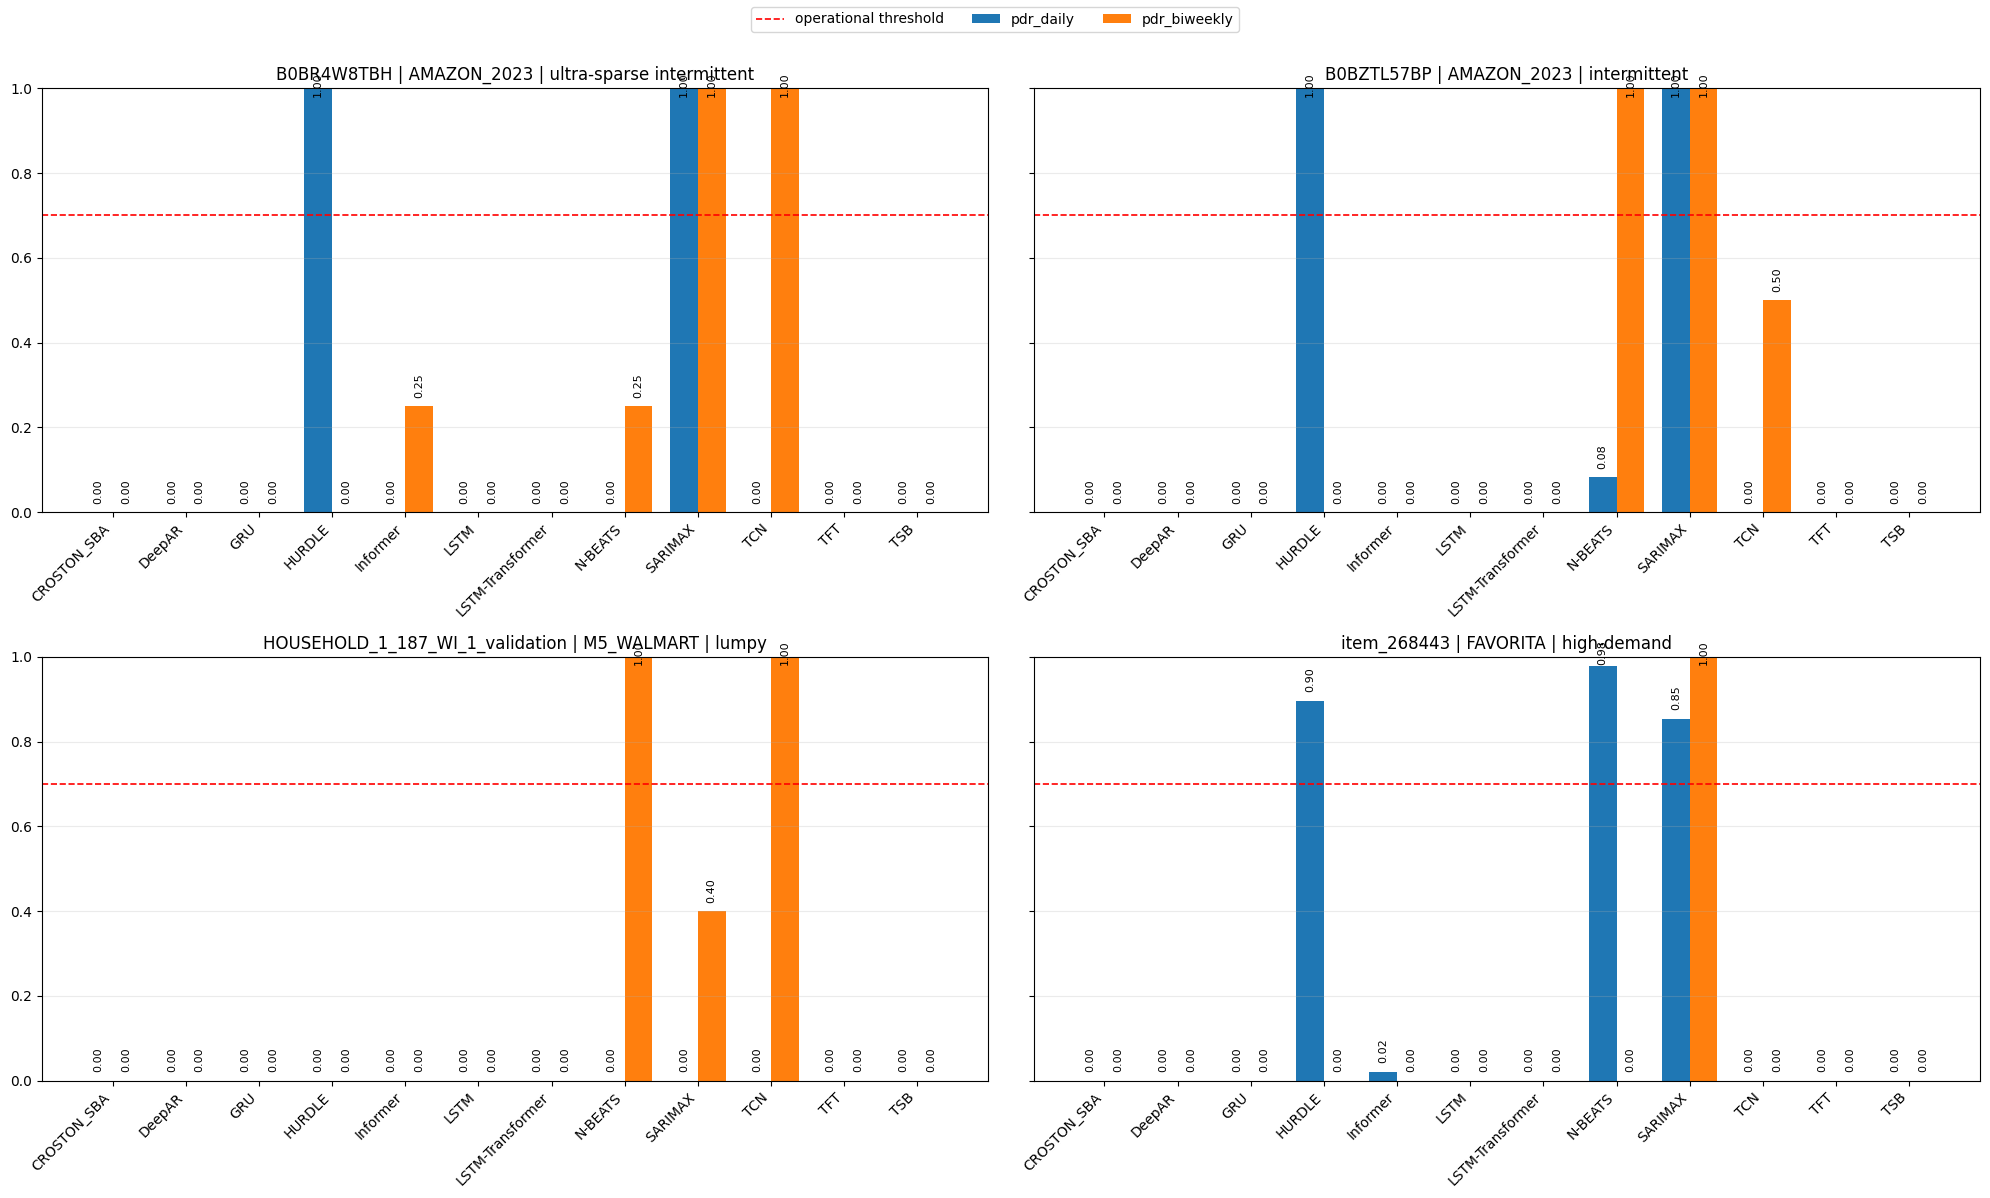

In [36]:

if 'pdr_compare_df' not in globals() or pdr_compare_df.empty:
    raise RuntimeError('Run cell 14 first so pdr_compare_df is available.')

reports_dir = REPO_ROOT / 'reports' / 'paper_experiments'
reports_dir.mkdir(parents=True, exist_ok=True)
series_meta = {
    row['series_id']: (row['dataset'], row['expected_regime'])
    for _, row in pdr_compare_df[['series_id', 'dataset', 'expected_regime']].drop_duplicates().iterrows()
}
series_ids = list(pdr_compare_df['series_id'].dropna().unique())[:4]
fig, axes = plt.subplots(2, 2, figsize=(20, 12), sharey=True)
axes = axes.flatten()

for ax_idx, sid in enumerate(series_ids):
    ax = axes[ax_idx]
    sub = pdr_compare_df[pdr_compare_df['series_id'] == sid].copy().sort_values('model')
    x = np.arange(len(sub))
    width = 0.38
    daily_vals = sub['pdr_daily'].fillna(0).to_numpy(dtype=float)
    biweekly_vals = sub['pdr_biweekly'].fillna(0).to_numpy(dtype=float)

    bars1 = ax.bar(x - width / 2, daily_vals, width=width, color='#1f77b4', label='pdr_daily')
    bars2 = ax.bar(x + width / 2, biweekly_vals, width=width, color='#ff7f0e', label='pdr_biweekly')
    ax.axhline(0.70, color='red', linestyle='--', linewidth=1.2, label='operational threshold' if ax_idx == 0 else None)
    dataset, demand_type = series_meta.get(sid, ('UNKNOWN', 'UNKNOWN'))
    ax.set_title(f'{sid} | {dataset} | {demand_type}')
    ax.set_xticks(x)
    ax.set_xticklabels(sub['model'], rotation=45, ha='right')
    ax.set_ylim(0.0, 1.0)
    ax.grid(axis='y', alpha=0.25)

    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width() / 2, min(height + 0.02, 0.98), f'{height:.2f}', ha='center', va='bottom', fontsize=8, rotation=90)

for ax in axes[len(series_ids):]:
    ax.axis('off')

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=3)
fig.tight_layout(rect=[0, 0, 1, 0.96])
chart_path = reports_dir / '28_pdr_daily_vs_biweekly.png'
fig.savefig(chart_path, dpi=150, bbox_inches='tight')
print(f'Saved figure to {chart_path}')
display(fig)
plt.close(fig)


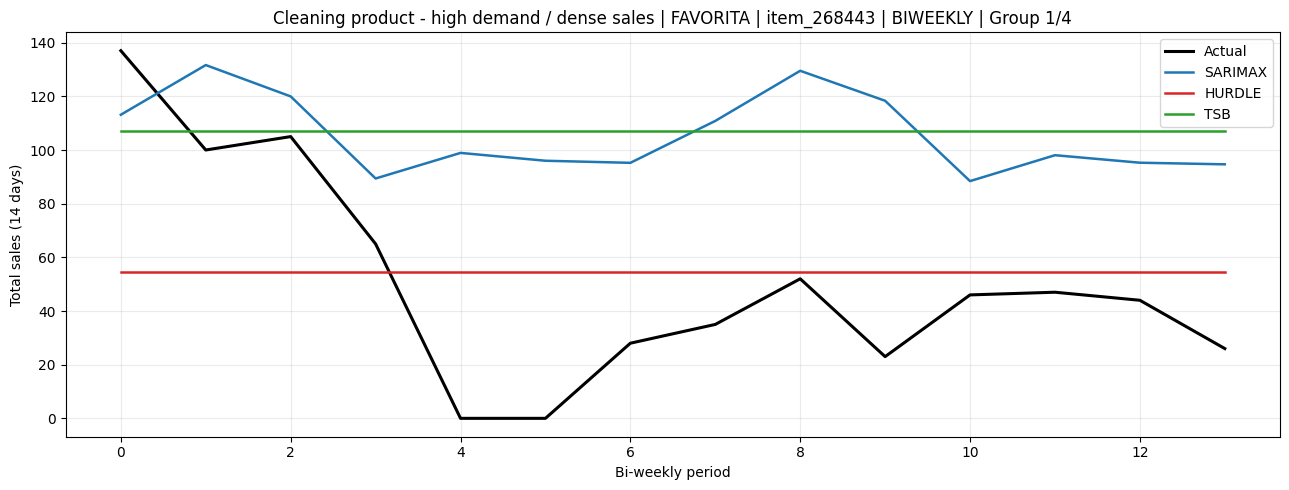

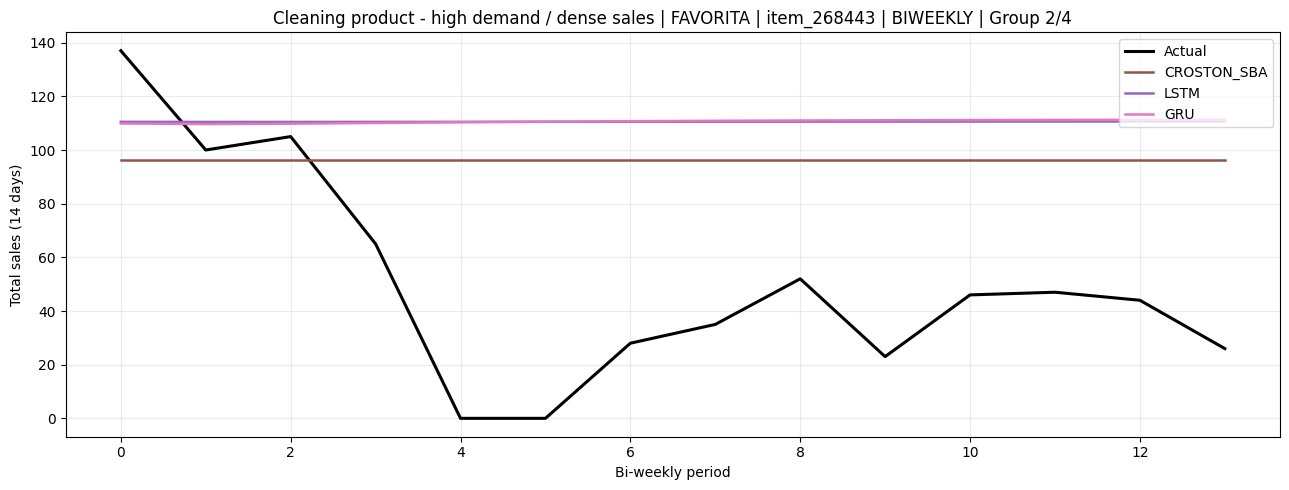

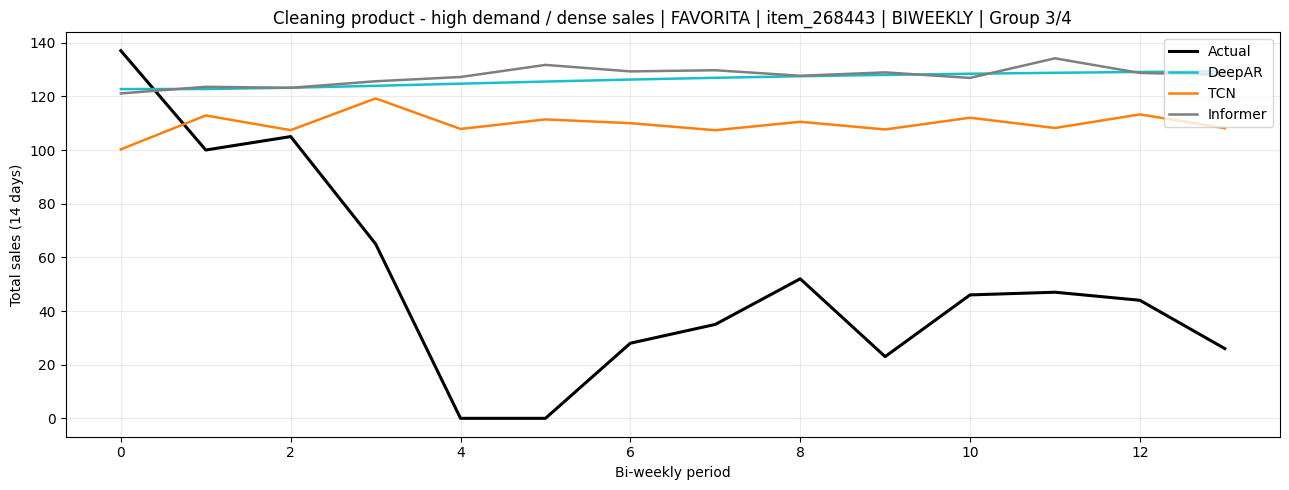

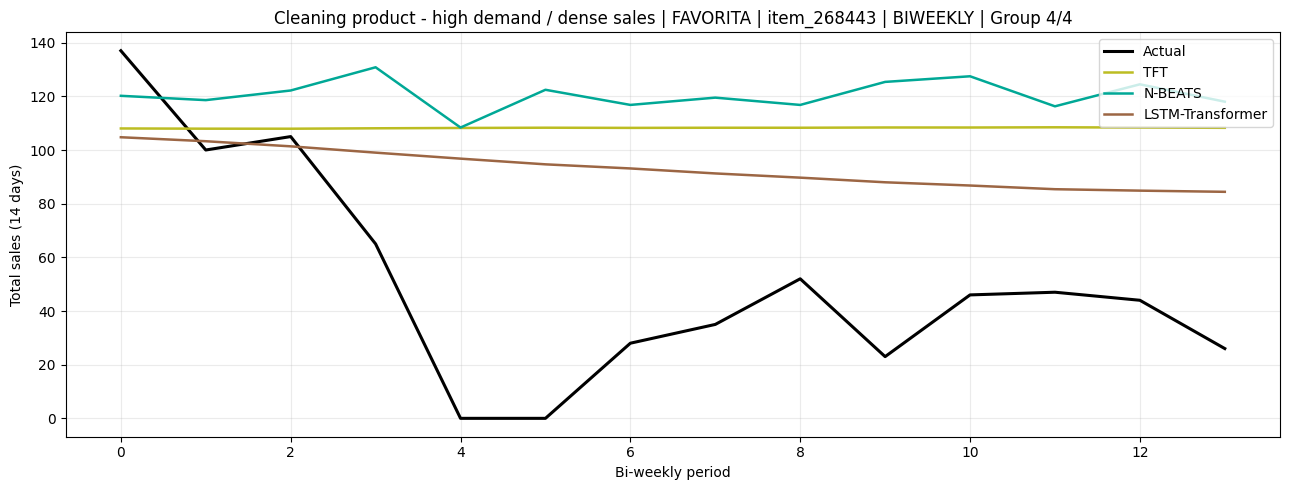

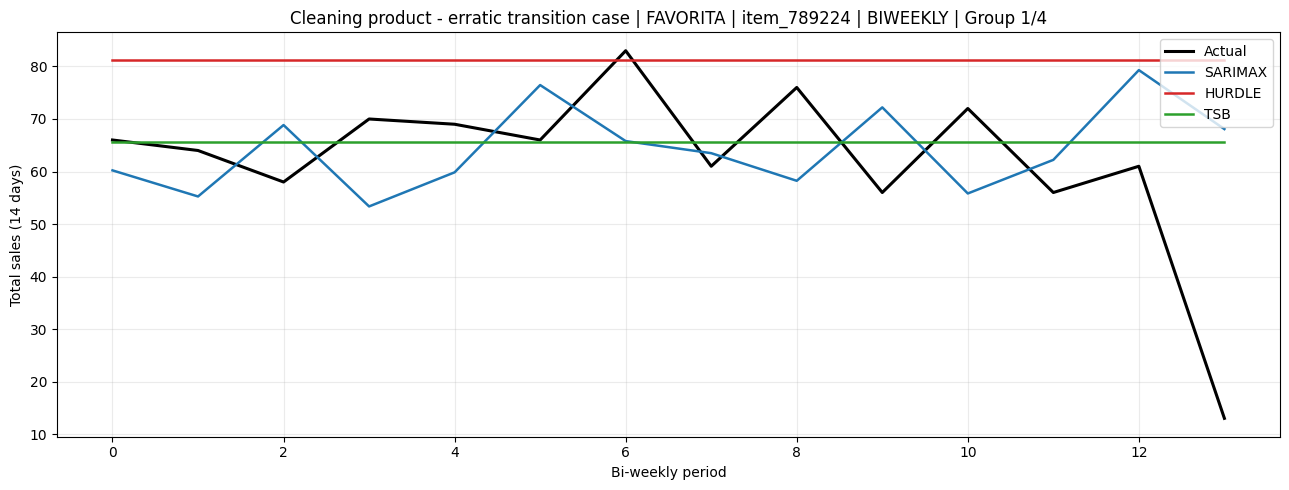

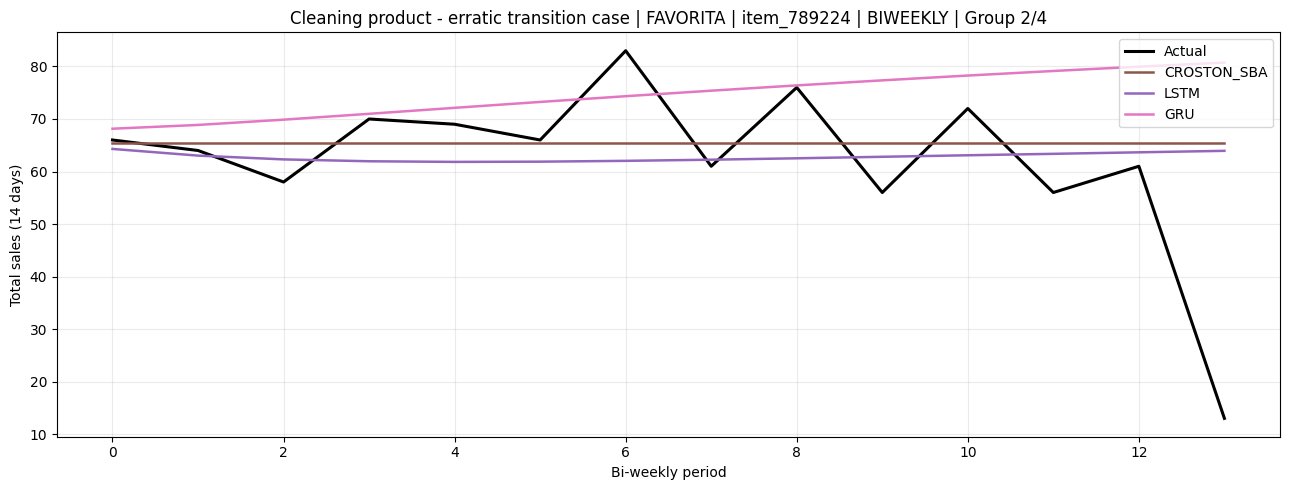

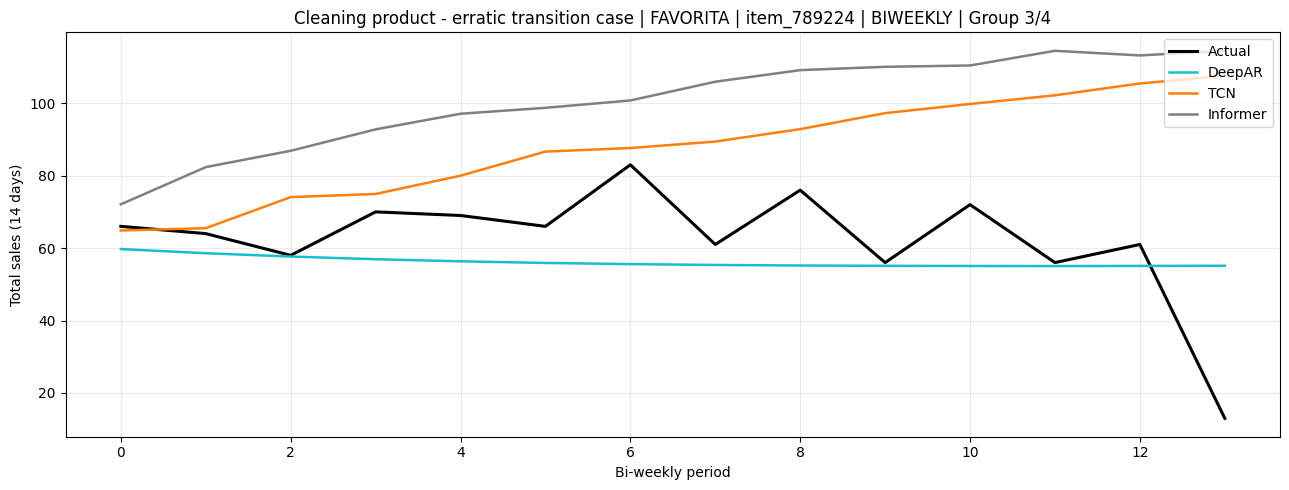

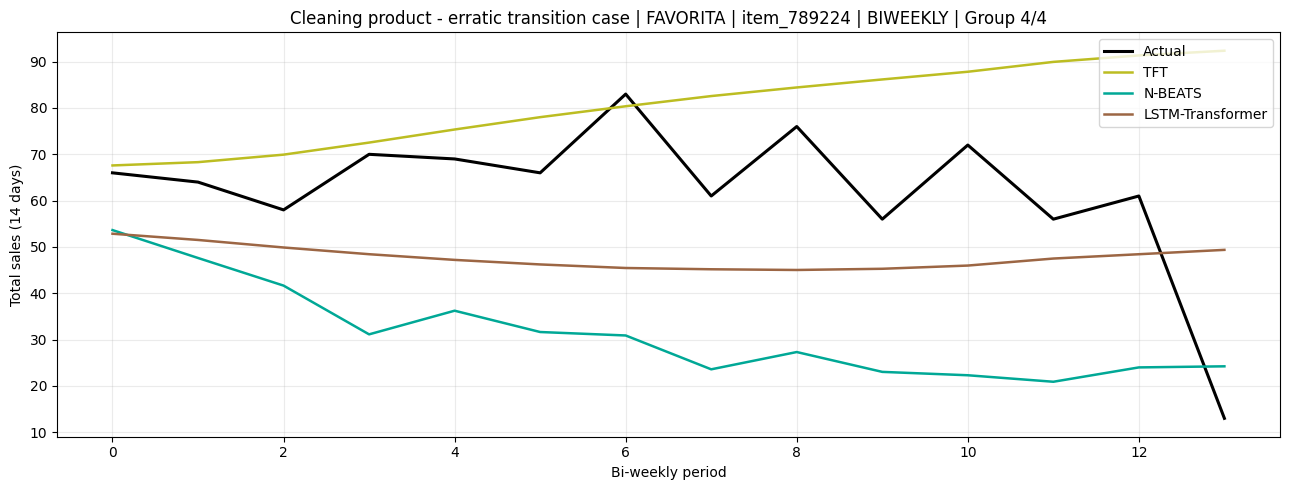

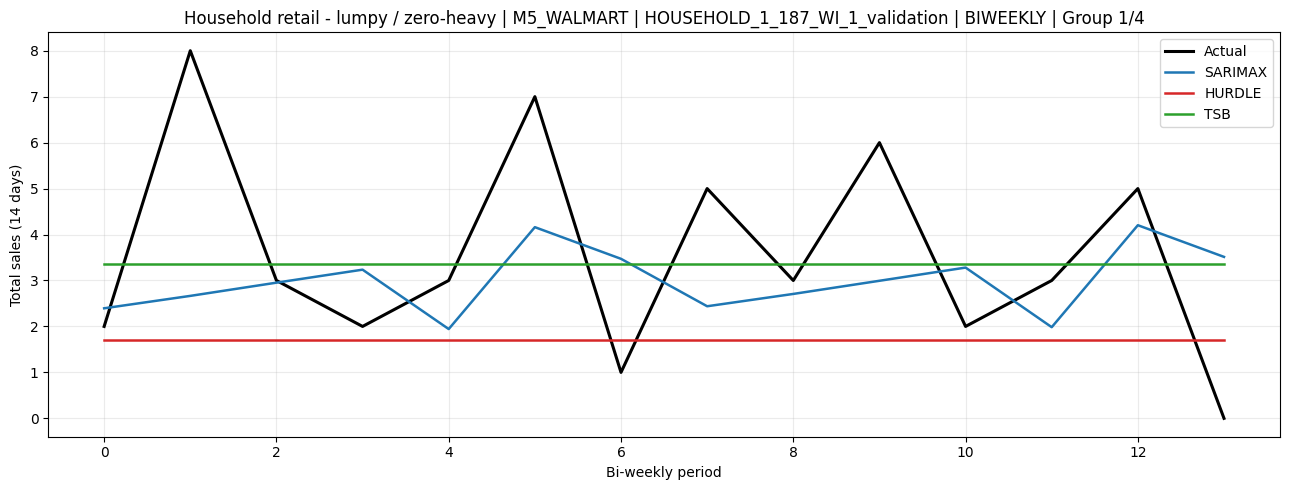

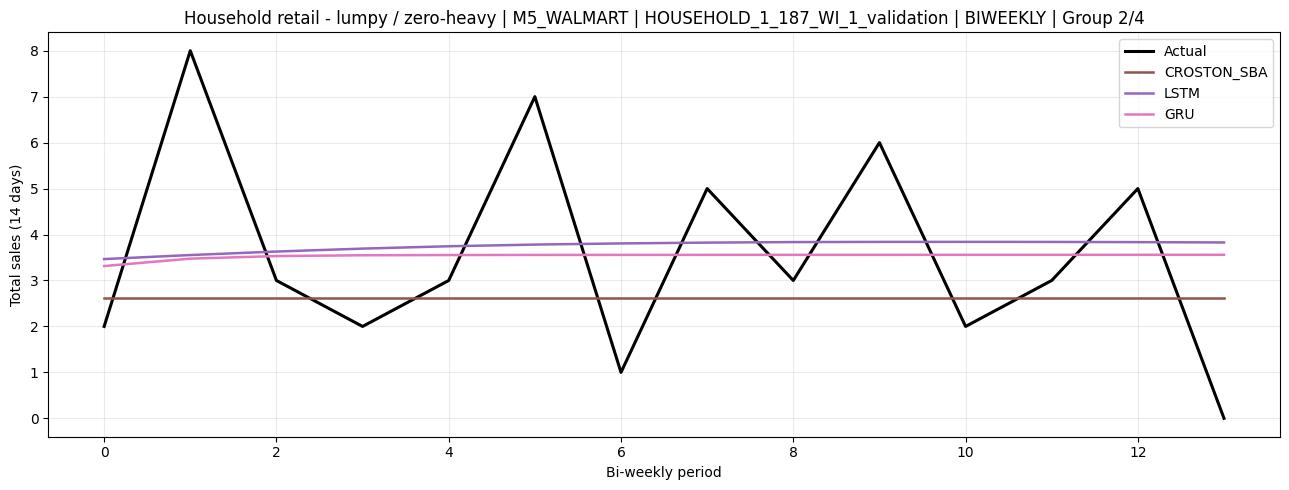

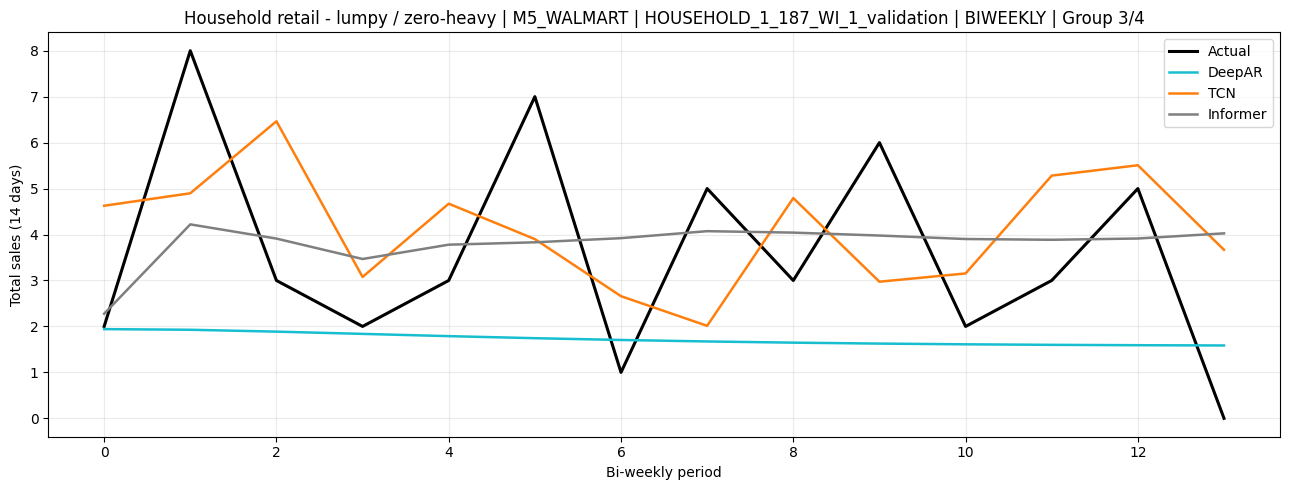

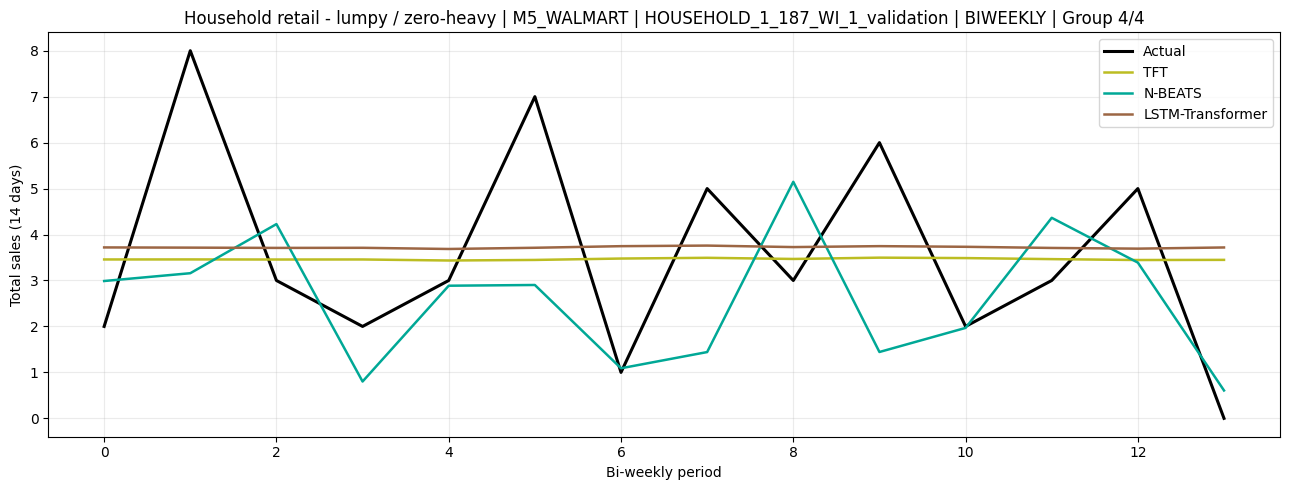

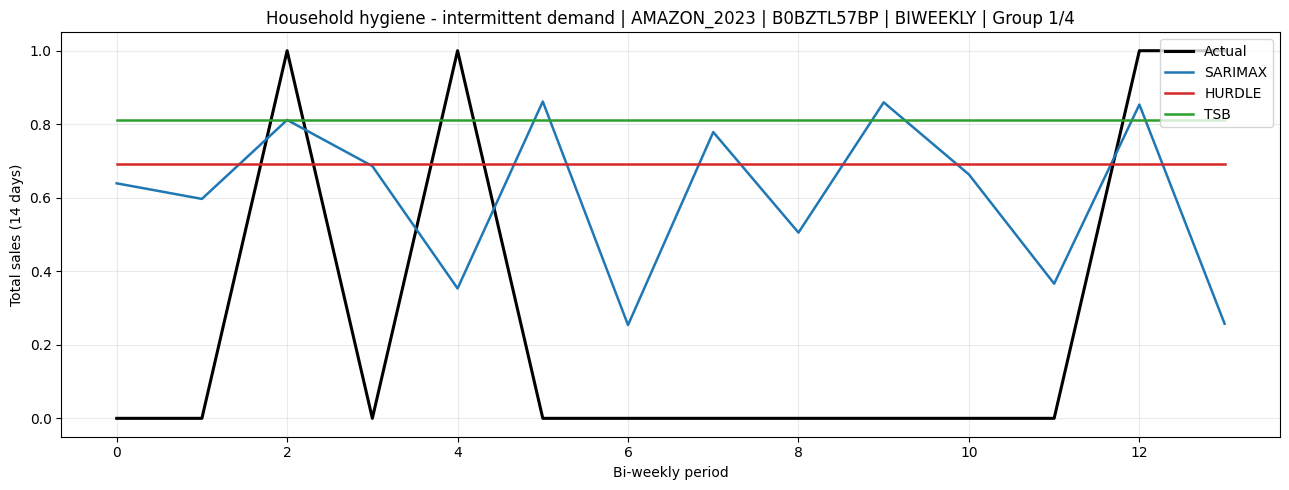

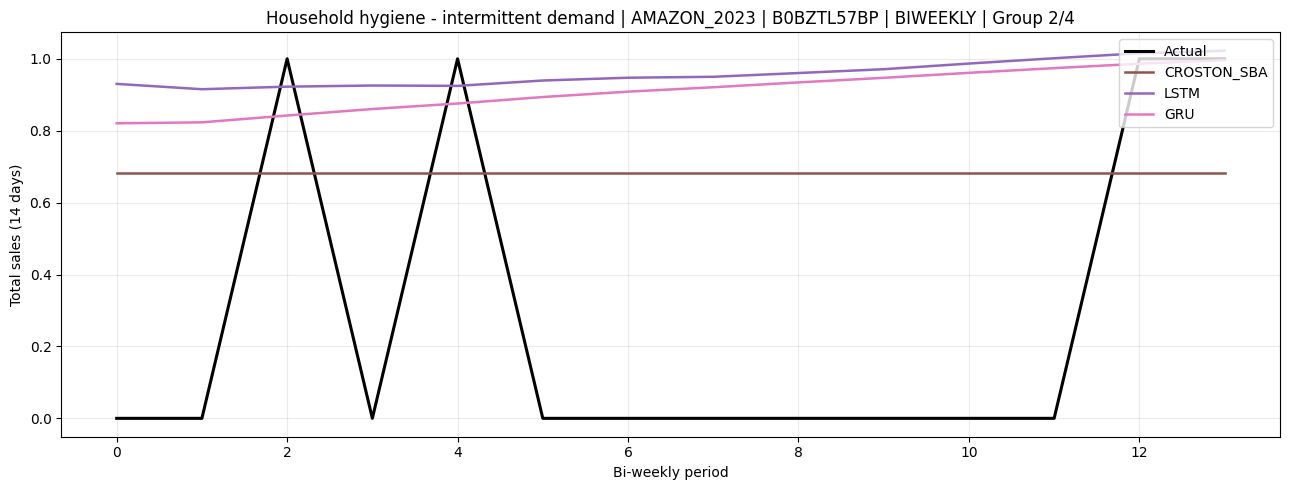

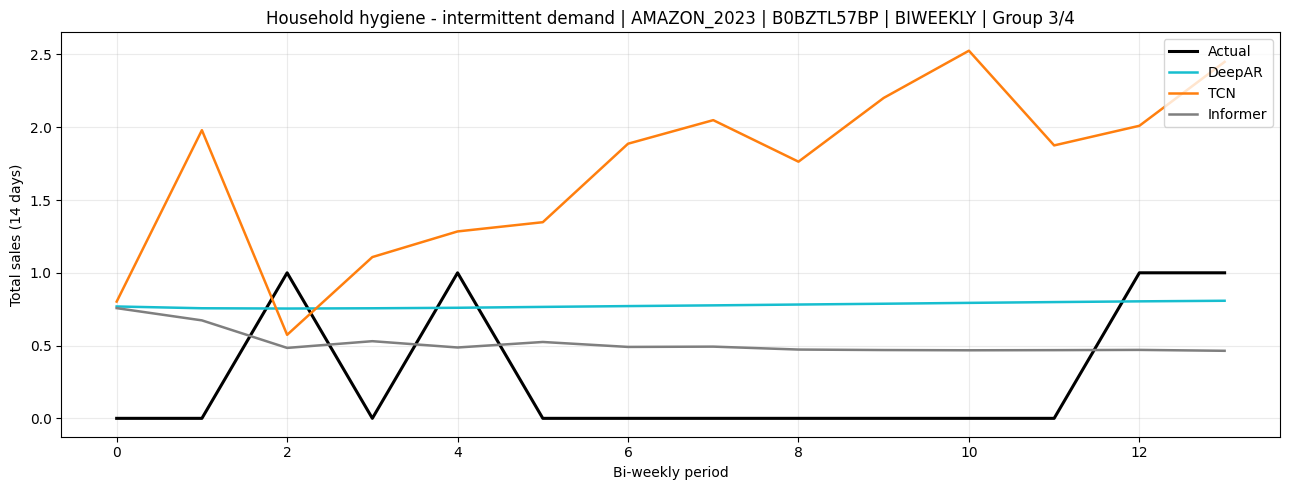

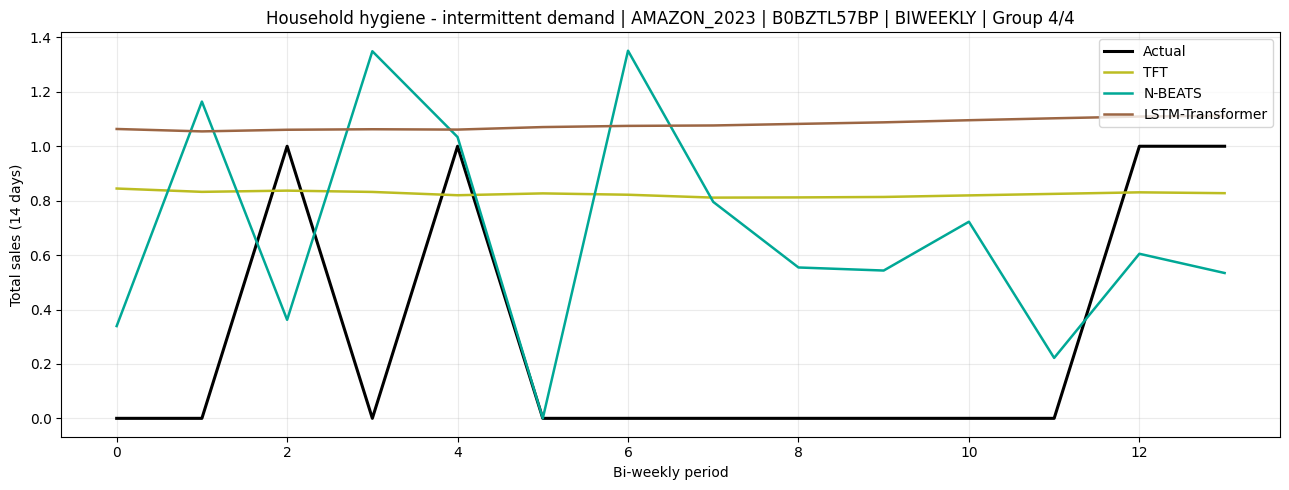

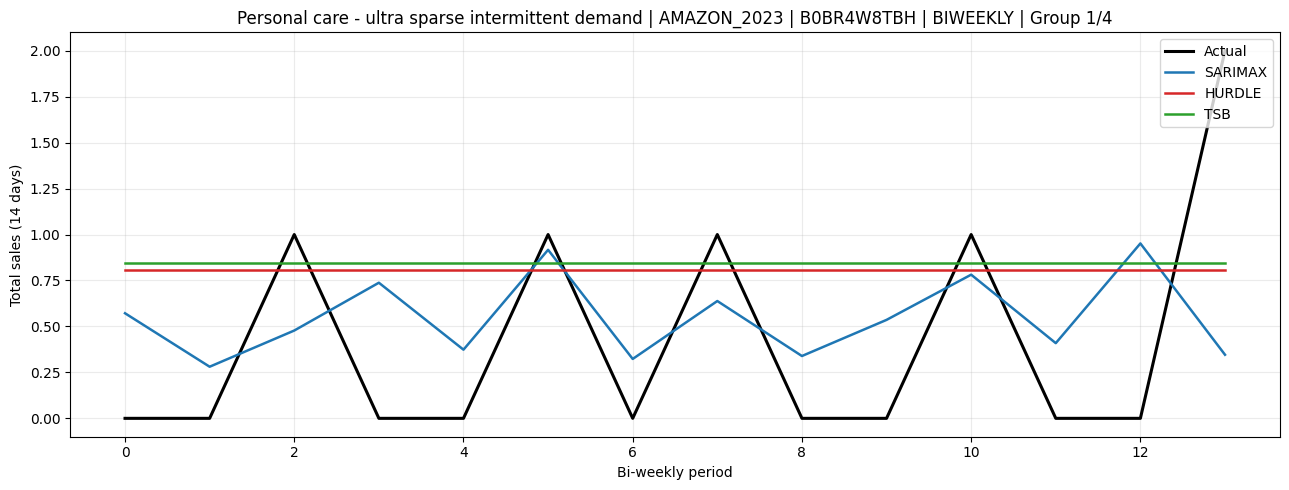

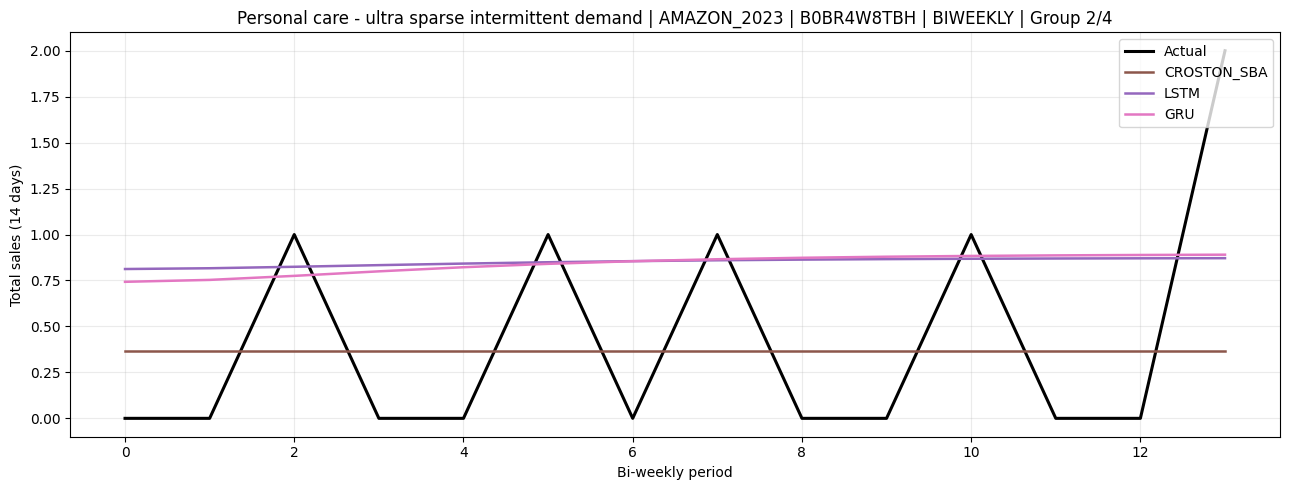

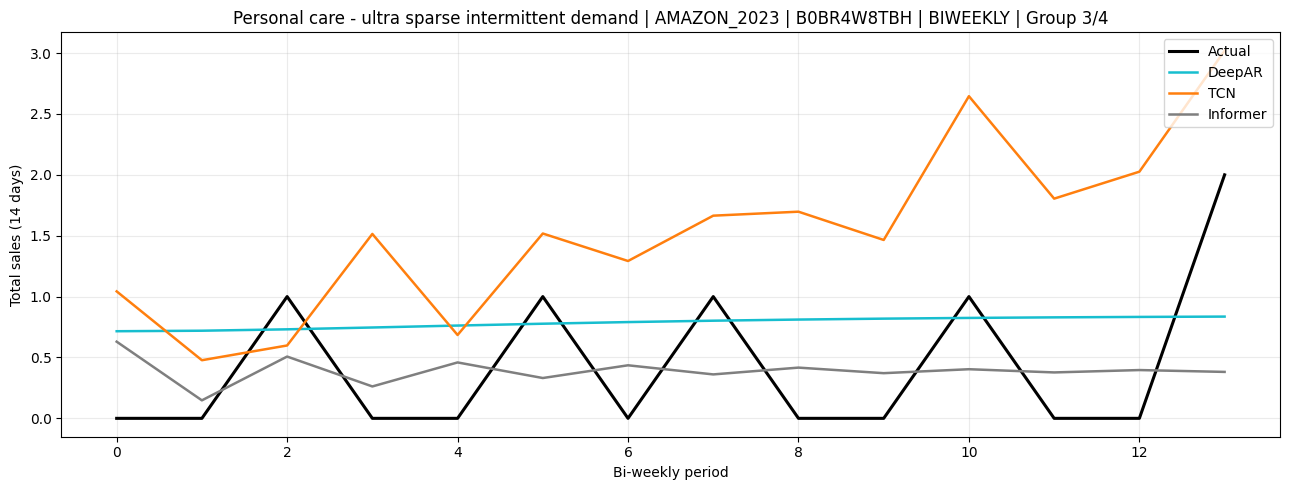

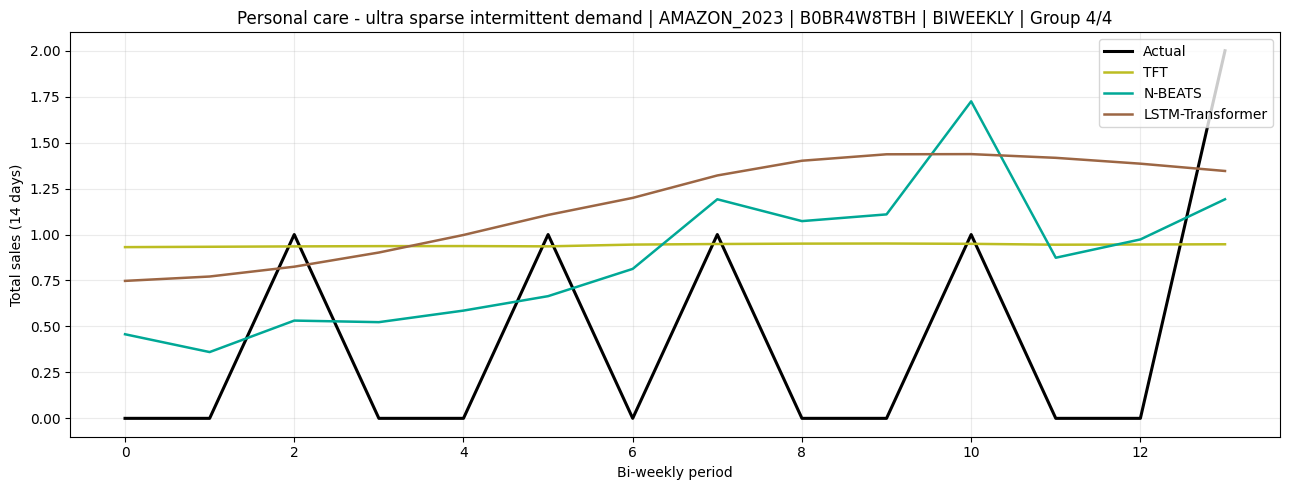

In [37]:

plot_groups = [
    ['SARIMAX', 'HURDLE', 'TSB'],
    ['CROSTON_SBA', 'LSTM', 'GRU'],
    ['DeepAR', 'TCN', 'Informer'],
    ['TFT', 'N-BEATS', 'LSTM-Transformer'],
]
color_map = {
    'Actual': 'black',
    'SARIMAX': '#1f77b4',
    'HURDLE': '#d62728',
    'TSB': '#2ca02c',
    'CROSTON_SBA': '#8c564b',
    'LSTM': '#9467bd',
    'GRU': '#e377c2',
    'DeepAR': '#17becf',
    'TCN': '#ff7f0e',
    'Informer': '#7f7f7f',
    'TFT': '#bcbd22',
    'N-BEATS': '#00a896',
    'LSTM-Transformer': '#9c6644',
}

for case in experiment_cases:
    case_rows = [r for r in results_bw if r['dataset'] == case['dataset'] and r['series_id'] == case['series_id']]
    if not case_rows:
        continue
    row_map = {row['model']: row for row in case_rows}
    case_chunks = []
    for group in plot_groups:
        chunk_rows = [row_map[m] for m in group if m in row_map]
        if chunk_rows:
            case_chunks.append((group, chunk_rows))
    for chunk_idx, (group_names, chunk_rows) in enumerate(case_chunks, start=1):
        fig, ax = plt.subplots(figsize=(13, 5))
        ax.plot(
            np.arange(len(case_rows[0]['y_test'])),
            case_rows[0]['y_test'],
            label='Actual',
            color=color_map['Actual'],
            linewidth=2.2,
        )
        for row in chunk_rows:
            ax.plot(
                np.arange(len(row['y_pred'])),
                row['y_pred'],
                label=row['model'],
                color=color_map.get(row['model']),
                linewidth=1.8,
            )
        ax.set_title(
            f"{case['semantic_product']} | {case['dataset']} | {case['series_id']} | BIWEEKLY | Group {chunk_idx}/{len(case_chunks)}"
        )
        ax.set_xlabel('Bi-weekly period')
        ax.set_ylabel('Total sales (14 days)')
        ax.legend(loc='upper right')
        ax.grid(alpha=0.25)
        plt.tight_layout()
        display(fig)
        plt.close(fig)


In [38]:

summary_rows = []
for case in experiment_cases:
    sid = case['series_id']
    prepared_bw = prepared_bw_cache[(case['dataset'], sid)]
    summary_rows.append({
        'series_id': sid,
        'dataset': case['dataset'],
        'daily_zero_rate': prepared_bw['daily_zero_rate'],
        'biweekly_zero_rate': prepared_bw['biweekly_zero_rate'],
        'zero_rate_reduction': prepared_bw['daily_zero_rate'] - prepared_bw['biweekly_zero_rate'],
    })

summary_df = pd.DataFrame(summary_rows).sort_values(['dataset', 'series_id']).reset_index(drop=True)
summary_path = REPO_ROOT / 'reports' / 'paper_experiments' / '28_biweekly_summary.csv'
summary_df.to_csv(summary_path, index=False)

print('=' * 70)
print('NOTEBOOK 28 - BIWEEKLY AGGREGATION VERDICT')
print('=' * 70)
print()
print('KEY QUESTION: Does bi-weekly aggregation fix the flat-forecast')
print('problem for deep learning models?')
print()
print('ZERO-RATE TRANSFORMATION:')
for _, row in summary_df.iterrows():
    reduction_pct = 100.0 * row['zero_rate_reduction'] / row['daily_zero_rate'] if row['daily_zero_rate'] > 0 else 0.0
    print(
        f"  {row['series_id']:35s} {row['daily_zero_rate']:.3f} -> {row['biweekly_zero_rate']:.3f} "
        f"(reduction={reduction_pct:.1f}%)"
    )
print()
print('PDR CHANGE (daily -> biweekly):')
challenger_improvements = []
for _, row in pdr_compare_df.sort_values(['series_id', 'model']).iterrows():
    print(
        f"  {row['series_id']:35s} | {row['model']:18s} | daily={row['pdr_daily'] if pd.notna(row['pdr_daily']) else float('nan'):.3f} "
        f"-> biweekly={row['pdr_biweekly'] if pd.notna(row['pdr_biweekly']) else float('nan'):.3f} | improved={row['improved']}"
    )
    if row['model'] in model_factories_bw and model_factories_bw[row['model']]['group'] == 'challenger_model':
        if pd.notna(row['pdr_daily']) and pd.notna(row['pdr_biweekly']) and row['pdr_daily'] == 0 and row['pdr_biweekly'] > 0:
            challenger_improvements.append((row['series_id'], row['model'], row['pdr_biweekly']))
print()
print('CONCLUSION:')
if challenger_improvements:
    improved_models = ', '.join(f"{model} on {sid} (PDR={pdr:.3f})" for sid, model, pdr in challenger_improvements)
    print(f'  Aggregation partially fixes flat-forecast for {improved_models}.')
    print('  However, SARIMAX/HURDLE still lead on PDR overall.')
else:
    print('  Even with bi-weekly aggregation, deep learning challengers')
    print('  do not achieve competitive PDR vs SARIMAX/HURDLE.')
    print("  This strengthens the paper's routing framework claim.")
print('=' * 70)
print(f'Saved summary to {summary_path}')


NOTEBOOK 28 - BIWEEKLY AGGREGATION VERDICT

KEY QUESTION: Does bi-weekly aggregation fix the flat-forecast
problem for deep learning models?

ZERO-RATE TRANSFORMATION:
  B0BR4W8TBH                          0.943 -> 0.472 (reduction=49.9%)
  B0BZTL57BP                          0.957 -> 0.562 (reduction=41.2%)
  item_268443                         0.176 -> 0.025 (reduction=85.9%)
  item_789224                         0.081 -> 0.000 (reduction=100.0%)
  HOUSEHOLD_1_187_WI_1_validation     0.926 -> 0.679 (reduction=26.7%)

PDR CHANGE (daily -> biweekly):
  B0BR4W8TBH                          | CROSTON_SBA        | daily=0.000 -> biweekly=0.000 | improved=no
  B0BR4W8TBH                          | DeepAR             | daily=0.000 -> biweekly=0.000 | improved=no
  B0BR4W8TBH                          | GRU                | daily=0.000 -> biweekly=0.000 | improved=no
  B0BR4W8TBH                          | HURDLE             | daily=1.000 -> biweekly=0.000 | improved=no
  B0BR4W8TBH           